# Amazon Electronics — Pipeline completo de SubSampling de datos
**Reviews + Metadata → Descarga → EDA → Limpieza → EDA → Merge → EDA → Sample**  
Cada etapa comprueba si su archivo de salida ya existe antes de ejecutarse.  
Semilla global = 42.

## 0 · Instalación de dependencias
Ejecutar solo la primera vez.

In [1]:
import sys
# Versiones fijadas para reproducibilidad total
!{sys.executable} -m pip install -q \
    polars==1.30.0 \
    duckdb==1.2.2 \
    matplotlib==3.10.1 \
    scikit-learn==1.6.1 \
    numpy==2.2.5
print("✓ Dependencias instaladas")


✓ Dependencias instaladas



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Se debe seguir las versiones de las dependencias instaladas o partes del código podrían fallar o no ejecutarse correctamente

## 1 · Imports y configuración

Este fragmento de código cumple principalmente una función de configuración inicial y preparación del entorno para un pipeline de procesamiento de datos (reviews y metadatos de Amazon). Se utiliza para dejar todo listo para que el resto del flujo funcione de forma controlada y reproducible.

Primero, importa una gran cantidad de librerías necesarias para distintas tareas: manejo de archivos (gzip, shutil, pathlib), procesamiento de datos (polars, numpy, pyarrow, duckdb), visualización (matplotlib), utilidades del sistema (os, sys, platform, tempfile) y otras como json o warnings. Luego desactiva advertencias para evitar ruido en la ejecución.

Después, establece una semilla global (SEED = 42) usando NumPy para reproducibilidad. También define una paleta de colores (PAL) que probablemente se usará en gráficos.

El núcleo del código es la clase Config, definida como un @dataclass. Esta clase centraliza toda la configuración del pipeline. En el método __post_init__, que se ejecuta automáticamente al crear la instancia de la clase, se generan y organizan todas las rutas de archivos del pipeline. Además, se asegura de que todas estas carpetas existan (creándolas si es necesario).

In [6]:
import gzip, re, shutil, sys, platform, tempfile, time, urllib.request, warnings
from dataclasses import dataclass, field
from pathlib import Path

import duckdb
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import polars as pl
from IPython.display import Image, display
import json
import pyarrow as pa
import pyarrow.parquet as pq_arrow
import pyarrow.compute as pc
import os
import random
import gc
from collections import defaultdict

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

PAL = ['#1D9E75','#378ADD','#EF9F27','#E24B4A','#7F77DD','#D4537E','#888780','#5DCAA5']


# CONFIGURACIÓN — editar esta seccion si es necesario, pero no es obligatorio

@dataclass
class Config:
    # Carpeta raíz de datos:
    #   Windows : DATA_DIR = Path(r'C:\Datasets\amazon')
    #   Colab   : DATA_DIR = Path('/content/drive/MyDrive/amazon')
    #   Default : carpeta '../data' relativa al notebook
    DATA_DIR: Path = Path('..') / 'data'

    # Tamaño del sample final para ML (estratificado por rating)
    SAMPLE_N: int = 1_000_000

    # Umbrales reviews, se pueden modificar
    # minima y maxima cantidad de caracteres en el campo de texto de la review
    REV_MIN_CHARS: int   = 30
    REV_MAX_CHARS: int   = 2_500
    # porcentaje máximo de mayúsculas (para filtrar reviews con texto no legible)
    REV_CAPS_RATIO: float = 0.6
    REV_REPEAT_N: int   = 5
    # rating mínimo y máximo permitido (para filtrar reviews con ratings inválidos)
    REV_RATING_MIN: float = 1.0
    REV_RATING_MAX: float = 5.0
    # columnas a eliminar de reviews
    REV_DROP: list = field(default_factory=lambda: ['images','asin','user_id'])
    # helpful_vote mínimo y maximo permitido (para filtrar reviews con votos útiles inválidos)
    REV_HELPFUL_MIN: int = 0
    REV_HELPFUL_MAX: int = 30_000

    # Columnas requeridas en reviews (se valida al cargar)
    REV_REQUIRED_COLS: list = field(default_factory=lambda: [
        'rating','title','text','parent_asin',
        'timestamp','verified_purchase','helpful_vote',
    ])

    # Umbrales metadata 
    # columnas a eliminar de metadata (no aportan información relevante)
    META_DROP: list  = field(default_factory=lambda: ['images','videos','store','bought_together', 'subtitle', 'author'])
    # precio mínimo y máximo permitido (para filtrar productos con precios inválidos)
    META_PRICE_MIN: float = 0.01
    META_PRICE_MAX: float = 50_000.0
    

    # Columnas requeridas en metadata (se valida al cargar)
    META_REQUIRED_COLS: list = field(default_factory=lambda: [
        'main_category','title','average_rating','rating_number',
        'features','description','price','parent_asin', 'categories', 'details',
    ])

    # URLs descarga (no editar) Fuente de datos original
    URL_REVIEWS: str = ("https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/Electronics.jsonl.gz")
    URL_META: str = ("https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/meta_categories/meta_Electronics.jsonl.gz")

    def __post_init__(self):
        # Crear carpetas necesarias y definir paths
        # Nota: los archivos de salida se generan en una subcarpeta 'processed' dentro de DATA_DIR
        self.DATA_DIR.mkdir(parents=True, exist_ok=True)
        self.RAW_REVIEWS = self.DATA_DIR / 'Electronics.jsonl'
        self.RAW_META = self.DATA_DIR / 'meta_Electronics.jsonl'
        tmp = Path(tempfile.gettempdir()) / 'amz_pipe'
        tmp.mkdir(parents=True, exist_ok=True)
        self.TMP_REV_PQ = tmp / 'reviews_raw.parquet'
        self.TMP_META_PQ = tmp / 'meta_raw.parquet'
        proc = self.DATA_DIR / 'processed'
        proc.mkdir(parents=True, exist_ok=True)
        self.OUT_REV = proc / 'reviews_clean.parquet'
        self.OUT_META = proc / 'meta_clean.parquet'
        self.OUT_MERGED = proc / 'merged.parquet'
        self.OUT_SAMPLE = proc / 'sample_ml.parquet'
        self.REPORTS = proc / 'reports'
        self.REPORTS.mkdir(parents=True, exist_ok=True)


CFG = Config()
IS_COLAB = 'google.colab' in sys.modules

print(f"Entorno : {'Google Colab' if IS_COLAB else platform.system()+' local'}")
print(f"Python : {sys.version.split()[0]} Polars: {pl.__version__} DuckDB: {duckdb.__version__}")
print(f"DATA_DIR : {CFG.DATA_DIR.resolve()}")
print(f"SEED : {SEED}")


Entorno : Windows local
Python : 3.13.3 Polars: 1.30.0 DuckDB: 1.2.2
DATA_DIR : E:\SEMESTRE-1-2026\ML\data
SEED : 42


## 2 · Helpers compartidos
CleaningReport, funciones de gráficos y validación de esquema.

La clase CleaningReport se encarga de llevar un registro del proceso de limpieza: guarda cuántas filas había al inicio, cuántas se eliminan en cada paso y cuántas quedan. Permite imprimir avances (snap), registrar cada filtro aplicado (rec) y al final generar un resumen completo (summary), incluyendo exportación a CSV y un gráfico.

Luego hay varias funciones de visualización:

1. _bar_report genera un gráfico de barras con las filas eliminadas por cada paso.
2. plot_hist crea histogramas (distribuciones).
3. plot_bar dibuja gráficos de barras (verticales u horizontales).
4. plot_scatter genera gráficos de dispersión.

Todas estas gráficas se guardan como imágenes y se muestran automáticamente.

La función validate_schema valida que un dataset tenga las columnas necesarias. Si falta alguna, lanza un error claro para evitar fallos posteriores.Finalmente, hay funciones auxiliares para limpieza de texto:

1.  _is_spam: detecta reviews sospechosas (muchas mayúsculas, repeticiones, solo símbolos, etc.).
2. _fingerprint: normaliza texto para identificar duplicados (minúsculas, sin símbolos, recortado).
3.  _clean_list_col: asegura que columnas tipo lista estén bien formateadas.

In [3]:
# CleaningReport
class CleaningReport:
    # Clase para llevar un registro de los pasos de limpieza, eliminaciones y generar un reporte final con estadísticas y gráficos.
    def __init__(self, name: str, total: int):
        self.name = name; self.n0 = total; self.cur = total
        self.steps = []; self.t0 = time.time()

    # Método para registrar un "snapshot" del número de filas en un punto del proceso, con una etiqueta descriptiva.
    def snap(self, label: str, n: int):
        print(f"  ── [{label}] {n:,} filas ({n/self.n0*100:.1f}% del original)")

    # Método para registrar un paso de limpieza, indicando el número de filas eliminadas, el porcentaje respecto al original, y una nota opcional.
    def rec(self, step: str, removed: int, note: str = ""):
        pct = removed / self.n0 * 100 if self.n0 else 0
        self.cur -= removed
        self.steps.append(dict(paso=step, eliminadas=removed,
                               pct=round(pct,3), restantes=self.cur, nota=note))
        print(f"  ✓  [{step:<44}]  -{removed:>9,} ({pct:5.2f}%)  → {self.cur:,}")

    # Método para generar un reporte final con estadísticas de limpieza, gráficos y exportar un CSV con el detalle de los pasos.
    def summary(self):
        removed = self.n0 - self.cur; pct_r = removed / self.n0 * 100
        sep = "─"*68
        print(f"\n{sep}"); print(f"  REPORTE — {self.name.upper()}"); print(sep)
        print(f"  Original  : {self.n0:>14,}")
        print(f"  Eliminadas: {removed:>14,}  ({pct_r:.2f}%)")
        print(f"  Finales   : {self.cur:>14,}  ({100-pct_r:.2f}% retenidas)")
        print(f"  Tiempo    : {(time.time()-self.t0)/60:.1f} min"); print(sep)
        for s in self.steps:
            bar  = "█" * max(1, int(s['pct']*1.5))
            note = f"  ← {s['nota']}" if s['nota'] else ""
            print(f"  {s['paso']:<46}  -{s['eliminadas']:>9,}  {bar}{note}")
        print(sep)
        df_rep = pl.DataFrame(self.steps)
        df_rep.write_csv(CFG.REPORTS / f'report_{self.name}.csv')
        _bar_report(df_rep, self.name)
        return df_rep

# Gráficos
# Función para generar un gráfico de barras horizontal con los pasos de limpieza y el número de filas eliminadas, guardarlo como imagen y mostrarlo en el notebook.
def _bar_report(df: pl.DataFrame, name: str):
    fig, ax = plt.subplots(figsize=(9, max(3, len(df)*0.55)))
    colors = [PAL[i % len(PAL)] for i in range(len(df))]
    bars = ax.barh(df['paso'].to_list(), df['eliminadas'].to_list(), color=colors, height=0.55)
    ax.bar_label(bars, labels=[f'{v:,}' for v in df['eliminadas'].to_list()], padding=4, fontsize=9)
    ax.set_xlabel('Filas eliminadas'); ax.set_title(f'Limpieza — {name}', fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
    ax.invert_yaxis(); plt.tight_layout()
    path = CFG.REPORTS / f'cleaning_{name}.png'
    fig.savefig(path, dpi=130, bbox_inches='tight'); plt.close(fig)
    display(Image(str(path), width=700))

# Función para generar un histograma de una serie numérica, guardarlo como imagen y mostrarlo en el notebook.
def plot_hist(series: pl.Series, title: str, xlabel: str, fname: str,
              bins: int = 40, color: str = '#378ADD'):
    data = series.drop_nulls().to_list()
    if not data: return
    fig, ax = plt.subplots(figsize=(8,4))
    ax.hist(data, bins=bins, color=color, edgecolor='white', linewidth=0.4)
    ax.set_title(title, fontweight='bold'); ax.set_xlabel(xlabel); ax.set_ylabel('Frecuencia')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
    plt.tight_layout(); path = CFG.REPORTS / fname
    fig.savefig(path, dpi=130, bbox_inches='tight'); plt.close(fig)
    display(Image(str(path), width=700))

# Función para generar un gráfico de barras con etiquetas y valores personalizados, guardarlo como imagen y mostrarlo en el notebook.
def plot_bar(labels, values, title, xlabel, ylabel, fname, horizontal=False):
    fig, ax = plt.subplots(figsize=(9,4))
    colors = [PAL[i % len(PAL)] for i in range(len(labels))]
    if horizontal:
        bars = ax.barh(labels, values, color=colors, height=0.6)
        ax.bar_label(bars, labels=[f'{v:,}' for v in values], padding=4, fontsize=8)
        ax.set_xlabel(ylabel); ax.invert_yaxis()
    else:
        bars = ax.bar(labels, values, color=colors, width=0.6)
        ax.bar_label(bars, labels=[f'{v:,}' for v in values], padding=2, fontsize=8)
        ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
    plt.tight_layout(); path = CFG.REPORTS / fname
    fig.savefig(path, dpi=130, bbox_inches='tight'); plt.close(fig)
    display(Image(str(path), width=700))

# Función para generar un gráfico de dispersión entre dos series numéricas, guardarlo como imagen y mostrarlo en el notebook.
def plot_scatter(x, y, title, xlabel, ylabel, fname, xlim=None):
    fig, ax = plt.subplots(figsize=(7,4))
    ax.scatter(x, y, alpha=0.15, s=3, c=PAL[1])
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title, fontweight='bold')
    if xlim: ax.set_xlim(0, xlim)
    plt.tight_layout(); path = CFG.REPORTS / fname
    fig.savefig(path, dpi=130, bbox_inches='tight'); plt.close(fig)
    display(Image(str(path), width=700))

# Validación de esquema
def validate_schema(df: pl.LazyFrame | pl.DataFrame, required_cols: list, dataset_name: str):
    """
    Levanta ValueError si alguna columna requerida no está presente.
    Llama antes de cualquier transformación.
    """
    actual = df.columns if hasattr(df, 'columns') else df.schema.names()
    missing = [c for c in required_cols if c not in actual]
    if missing:
        raise ValueError(
            f"\n{'='*60}\n"
            f"  ERROR DE ESQUEMA — {dataset_name}\n"
            f"{'='*60}\n"
            f"  Columnas faltantes: {missing}\n"
            f"  Columnas presentes: {actual}\n"
            f"  Verifica que el archivo descargado sea el correcto.\n"
            f"{'='*60}"
        )
    print(f"  ✓ Esquema válido — {dataset_name} ({len(actual)} columnas, {len(required_cols)} requeridas)")

# Helpers spam / fingerprint para detectar el spam y generar una "huella" de texto para identificar reviews  duplicadas.
_repeat_re = re.compile(r'(.)\1{' + str(CFG.REV_REPEAT_N) + r',}')
_symbol_re = re.compile(r'^[\W\d\s]+$')
_clean_re  = re.compile(r'[^\w\s]')
_space_re  = re.compile(r'\s+')

# Función para detectar si un texto es spam o no, basado en reglas simples.
def _is_spam(text: str) -> bool:
    if not text: return True
    if sum(c.isupper() for c in text) / max(len(text),1) > CFG.REV_CAPS_RATIO: return True
    if _repeat_re.search(text): return True
    if _symbol_re.match(text.strip()): return True
    return False

# Función para generar una "huella" de texto, limpiando caracteres especiales, normalizando espacios y truncando a 200 caracteres. 
# Esto ayuda a identificar reviews similares o duplicadas.
def _fingerprint(text: str) -> str:
    t = _clean_re.sub('', text.lower())
    return _space_re.sub(' ', t).strip()[:200]

# Función para limpiar una columna que debería contener listas, pero puede tener valores nulos o mal formateados. 
# Intenta convertir a string y llenar nulos con '[]', si falla reemplaza toda la columna con '[]'.
def _clean_list_col(df: pl.DataFrame, col: str) -> pl.DataFrame:
    if col not in df.columns:
        return df
    try:
        return df.with_columns(
            pl.col(col).cast(pl.String).fill_null("[]")
        )
    except Exception as e:
        print(f"  ⚠ _clean_list_col('{col}'): {e} — reemplazando con '[]'")
        return df.with_columns(pl.lit("[]").alias(col))

print("✓ Helpers cargados")


✓ Helpers cargados


## 3 · Descarga y descompresión
Lógica de skip (en orden de prioridad):
1. `merged.parquet` existe → salta TODO (descarga, limpieza y merge innecesarios)
2. `Electronics.jsonl` existe → salta descarga de reviews
3. `meta_Electronics.jsonl` existe → salta descarga de metadata
4. `*.jsonl.gz` existe → solo descomprime, sin volver a descargar

Todo esto se hace para asegurarse de que el dataset siempre pueda recuperarse

In [11]:
if CFG.OUT_MERGED.exists():
    print(f"✓ merged.parquet ya existe ({CFG.OUT_MERGED.stat().st_size/1e9:.2f} GB)")
    print("  Saltando descarga completa.")
else:
    def _progress(count, block, total):
        if total > 0:
            pct = min(count*block/total*100, 100)
            print(f"\r  [{'█'*int(pct//5)+'░'*(20-int(pct//5))}] {pct:5.1f}%", end="", flush=True)

    def _decompress(gz: Path, out: Path):
        print(f"  Descomprimiendo {gz.name} → {out.name} …")
        with gzip.open(gz,'rb') as fi, open(out,'wb') as fo:
            shutil.copyfileobj(fi, fo)
        gz.unlink()
        print(f"     Listo: {out.stat().st_size/1e9:.2f} GB")

    def ensure_file(jsonl: Path, url: str, label: str):
        if jsonl.exists():
            print(f"  ✓  {jsonl.name} ya existe ({jsonl.stat().st_size/1e9:.2f} GB) — skip")
            return
        gz = jsonl.parent / (jsonl.name + '.gz')
        if not gz.exists():
            print(f"  ↓  Descargando {label} …  (puede tardar varios minutos)")
            urllib.request.urlretrieve(url, gz, reporthook=_progress); print()
        else:
            print(f"  ✓  {gz.name} ya existe — solo descomprimiendo")
        _decompress(gz, jsonl)

    print("[DESCARGA]")
    ensure_file(CFG.RAW_REVIEWS, CFG.URL_REVIEWS, "Electronics reviews")
    ensure_file(CFG.RAW_META, CFG.URL_META, "Electronics metadata")
    print("\n✓ Archivos raw listos")


✓ merged.parquet ya existe (22.70 GB)
  Saltando descarga completa.


## 4 · Conversión JSONL → Parquet y validación de esquema
DuckDB convierte en streaming sin cargar a RAM.  
Se valida que todas las columnas requeridas estén presentes — si falta alguna se lanza `ValueError`.


In [4]:
# Reviews 
def _convert_reviews() -> int:
    if CFG.OUT_MERGED.exists() or CFG.TMP_REV_PQ.exists():
        if CFG.OUT_MERGED.exists():
            print("  merged.parquet existe — skip conversión reviews")
            return 0
        print(f"  Parquet reviews tmp ya existe → {CFG.TMP_REV_PQ}")
    else:
        if not CFG.RAW_REVIEWS.exists():
            raise FileNotFoundError(f"No se encontró {CFG.RAW_REVIEWS}. Ejecuta la celda de descarga.")
        src = CFG.RAW_REVIEWS.resolve().as_posix()
        dest = CFG.TMP_REV_PQ.resolve().as_posix()
        CFG.TMP_REV_PQ.parent.mkdir(parents=True, exist_ok=True)
        print("  Convirtiendo reviews JSONL → Parquet (DuckDB) …")
        t0 = time.time()
        duckdb.sql(f"""COPY (SELECT * FROM read_ndjson('{src}',
                        auto_detect=true, ignore_errors=true))
                   TO '{dest}' (FORMAT PARQUET, ROW_GROUP_SIZE 200000, COMPRESSION 'zstd')""")
        print(f"  Convertido en {time.time()-t0:.0f}s")
    n = duckdb.sql(f"SELECT COUNT(*) FROM '{CFG.TMP_REV_PQ.resolve().as_posix()}'").fetchone()[0]
    return n

# Metadata
def _convert_meta() -> int:
    if CFG.OUT_MERGED.exists() or CFG.TMP_META_PQ.exists():
        if CFG.OUT_MERGED.exists():
            print("  merged.parquet existe — skip conversión metadata")
            return 0
        print(f"  Parquet meta tmp ya existe → {CFG.TMP_META_PQ}")
    else:
        if not CFG.RAW_META.exists():
            raise FileNotFoundError(f"No se encontró {CFG.RAW_META}. Ejecuta la celda de descarga.")
        src = CFG.RAW_META.resolve().as_posix()
        dest = CFG.TMP_META_PQ.resolve().as_posix()
        CFG.TMP_META_PQ.parent.mkdir(parents=True, exist_ok=True)
        print("  Convirtiendo meta JSONL → Parquet (DuckDB) …")
        t0 = time.time()
        duckdb.sql(f"""COPY (SELECT * FROM read_ndjson('{src}',
                        auto_detect=true, ignore_errors=true, maximum_depth=3))
                   TO '{dest}' (FORMAT PARQUET, ROW_GROUP_SIZE 100000, COMPRESSION 'zstd')""")
        print(f"  Convertido en {time.time()-t0:.0f}s")
    n = duckdb.sql(f"SELECT COUNT(*) FROM '{CFG.TMP_META_PQ.resolve().as_posix()}'").fetchone()[0]
    return n

print("[CONVERSIÓN + VALIDACIÓN DE ESQUEMA]")

# Reviews
_N_REV = _convert_reviews()
if not CFG.OUT_MERGED.exists():
    _df_rev_raw = pl.scan_parquet(CFG.TMP_REV_PQ.resolve().as_posix())
    validate_schema(_df_rev_raw, CFG.REV_REQUIRED_COLS, "Electronics reviews")
    print(f"  Columnas reviews: {_df_rev_raw.columns}")
    print(f"  Total filas    : {_N_REV:,}")

# Metadata
_N_META = _convert_meta()
if not CFG.OUT_MERGED.exists():
    _df_meta_raw = pl.scan_parquet(CFG.TMP_META_PQ.resolve().as_posix())
    validate_schema(_df_meta_raw, CFG.META_REQUIRED_COLS, "Electronics metadata")
    print(f"Columnas meta :{_df_meta_raw.columns}")
    print(f"Total filas : {_N_META:,}")

print("\n✓ Conversión y validación completas")


[CONVERSIÓN + VALIDACIÓN DE ESQUEMA]
  merged.parquet existe — skip conversión reviews
  merged.parquet existe — skip conversión metadata

✓ Conversión y validación completas


## 5 · EDA Reviews — antes de limpiar
Distribuciones sobre el dataset raw. Se puede ejecutar esta celda en cualquier momento.


[EDA REVIEWS PRE-LIMPIEZA]  fuente: reviews_raw.parquet


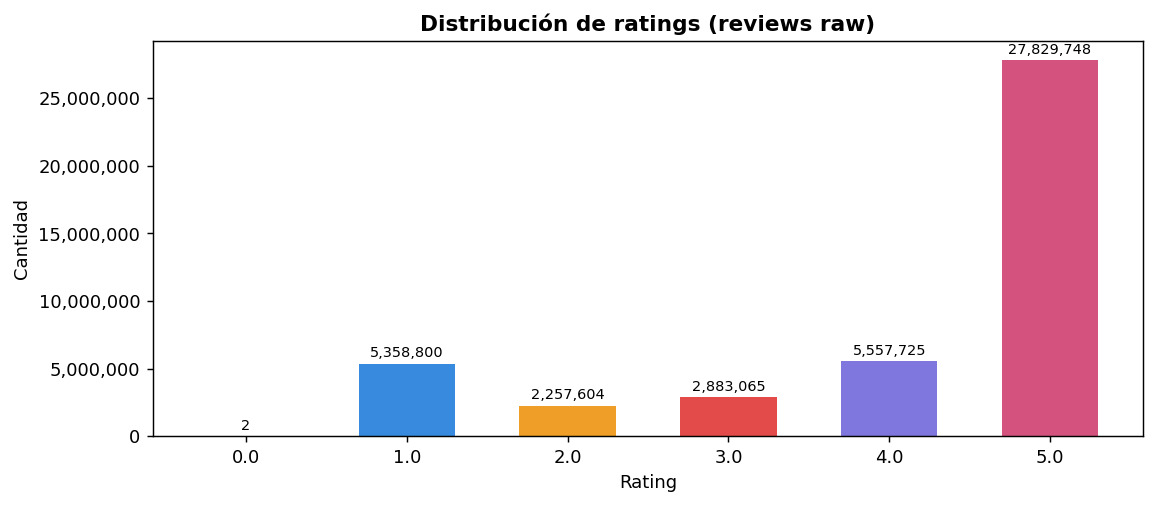

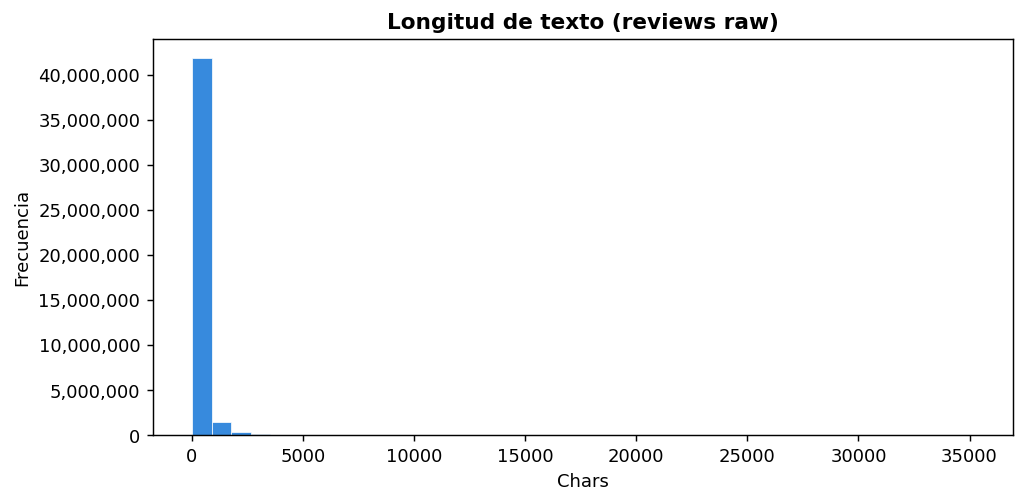

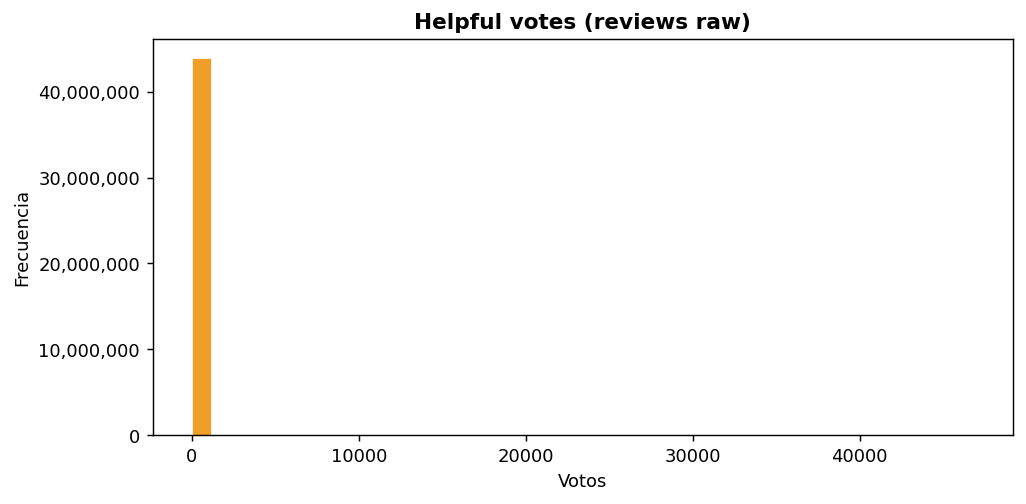

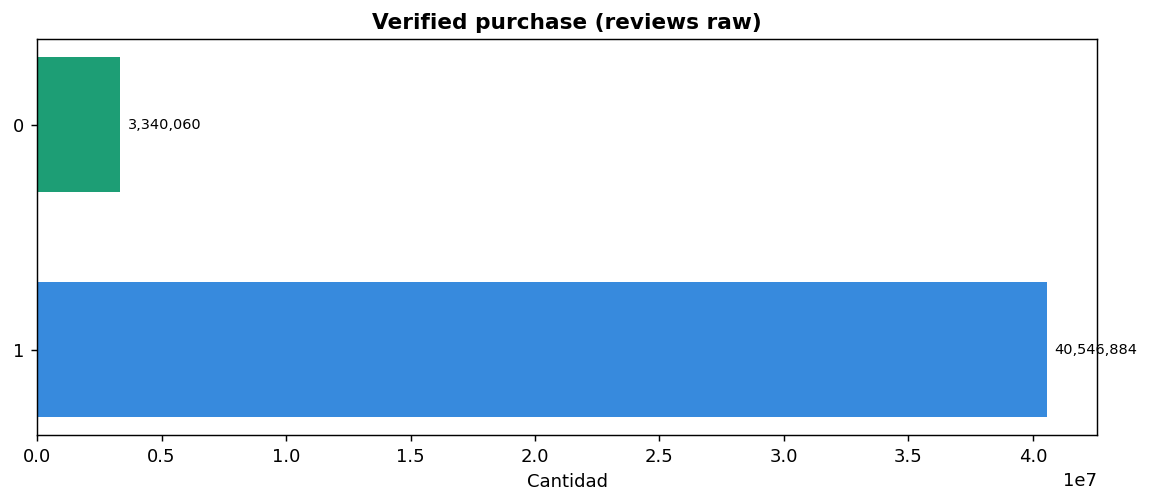

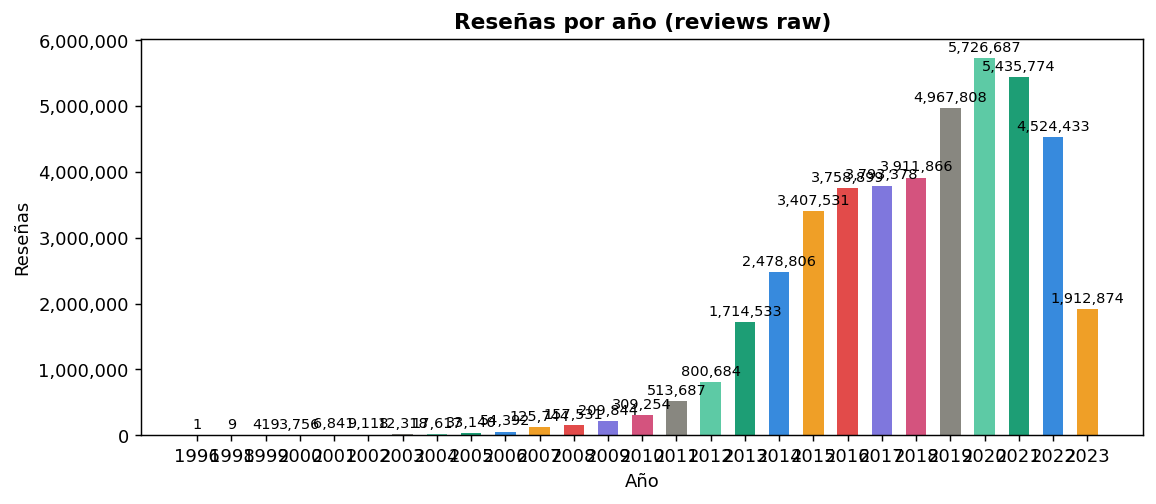


Estadísticas — reviews raw:


statistic,rating,text_len,helpful_vote
str,f64,f64,f64
"""count""",4.3886944e7,4.3886944e7,4.3886944e7
"""null_count""",0.0,0.0,0.0
"""mean""",4.099234,241.326955,1.090336
"""std""",1.41233,419.39731,22.575535
"""min""",0.0,0.0,-4.0
"""25%""",4.0,48.0,0.0
"""50%""",5.0,122.0,0.0
"""75%""",5.0,271.0,0.0
"""max""",5.0,35208.0,46841.0


In [27]:
if CFG.OUT_MERGED.exists() and not CFG.TMP_REV_PQ.exists():
    print("ℹ  merged.parquet ya existe y no hay parquet tmp — EDA pre no disponible.")
    print("  Borra merged.parquet y ejecuta desde la celda 3 para regenerar.")
else:
    _src_rev = (CFG.TMP_REV_PQ if CFG.TMP_REV_PQ.exists() else None)
    if _src_rev is None:
        print("ℹ  No hay datos de reviews disponibles. Ejecuta primero las celdas 3 y 4.")
    else:
        print(f"[EDA REVIEWS PRE-LIMPIEZA]  fuente: {_src_rev.name}")
        _s = pl.scan_parquet(_src_rev.resolve().as_posix()).select([
            pl.col("rating"),
            pl.col("text").str.len_chars().alias("text_len"),
            pl.col("helpful_vote"),
            pl.col("verified_purchase"),
            pl.col("timestamp"),
        ]).collect(engine="in-memory")

        # 1. Distribución de ratings
        rat = _s.group_by("rating").agg(pl.len().alias("n")).sort("rating")
        plot_bar([str(r) for r in rat["rating"].to_list()], rat["n"].to_list(),
                 "Distribución de ratings (reviews raw)", "Rating", "Cantidad",
                 "eda_rev_pre_ratings.png")

        # 2. Longitud de texto
        plot_hist(_s["text_len"], "Longitud de texto (reviews raw)", "Chars",
                  "eda_rev_pre_text_len.png")

        # 3. Helpful votes
        plot_hist(_s["helpful_vote"].drop_nulls(), "Helpful votes (reviews raw)", "Votos",
                  "eda_rev_pre_helpful.png", color='#EF9F27')

        # 4. Verified purchase
        vp = _s["verified_purchase"].value_counts().sort("verified_purchase")
        plot_bar([str(v) for v in vp["verified_purchase"].to_list()],
                 vp["count"].to_list(),
                 "Verified purchase (reviews raw)", "Verificado", "Cantidad",
                 "eda_rev_pre_verified.png", horizontal=True)

        # 5. Distribución temporal (por año)
        if _s["timestamp"].dtype in (pl.Int64, pl.Int32, pl.Float64):
            _s2 = _s.with_columns(
                pl.from_epoch(pl.col("timestamp").cast(pl.Int64), time_unit="ms")
                  .dt.year().alias("year"))
            yrs = _s2.group_by("year").agg(pl.len().alias("n")).sort("year").drop_nulls()
            plot_bar([str(y) for y in yrs["year"].to_list()], yrs["n"].to_list(),
                     "Reseñas por año (reviews raw)", "Año", "Reseñas",
                     "eda_rev_pre_years.png")

        # Estadísticas
        print("\nEstadísticas — reviews raw:")
        display(_s[["rating","text_len","helpful_vote"]].describe())


**OBSERVACIONES**
1. En el gráfico de reviews dsitribuido por los valores de rating se puede observar que la cantidad de reviews con cinco (El valor maximo posible) es mucho mas grande que cualquier otro valor que puede tomar, ademas se puede observar que existen dos reviews que estan fuera del rango de rating, por lo cual se necesita eliminar los valores que se encuentren en ese rango.
2. En el segundo grafico se puede observar que la longitud de texto raramente va a superar cierta cantidad de chars, especialmente mas allá de los 2000, entonces es un buen valor para filtrar valores mas grandes que posiblemente sean spam o errores en el scrapping
3. El tercer gráfico nos dice que una gran cantidad de reviews no tienen helpful votes, es decir que no son muy reconocidas, o la gran mayoría son reseñas normales que no tuvieron repercusión o de productos muy desconocidos o con pocas compras.
4. Existe una pequeña cantidad de reviews cuya compra no fue comprobada, esto nos puede decir que estas reviews son spam, o por lo menos se puede dudar de la veracidad de la reseña, ya que esta marca sirve para verificar que los usuarios compraron el producto, no lo consiguieron gratis y ademas de que lo usaron, por lo que dada la situacion, lo mejor es eliminar las reviews con estas columnas en false.
5. En este ultimo podemos ver que una gran cantidad de reviews vienen de los 202x, tambien se puede identificar la tendencia creciente de reviews mientras los años pasan.
6. Por ultimo en el resumen podemos observar algunas cosas, rating tiene dos reviews con cero lo cual no es posible, las review deberian encontrarse entre 1 y 5, ademas la media indica que la mayoria de datos estan acumulados en un rating de cinco. Por otra parte podemos observar que la longitud maxima de una review es de 35k char, lo cual es obviamente spam, un error a la hora de la recuperación de la review o un outlie que eleva la media demasiado, la media se encuentra en los 241 char que es algo muy adecuado para una review, por otra parte hay review vacias, sin texto las cuales no sirven a los objetivos de este proyecto por lo cual deben ser eliminadas. Por ultimo, en la columna de helpful_votes se pude observar que hay filas con valores invalidos (negativos), ademas de que existe un valor muy alto de 46k reviews positivas, pero la media se encuentra en 1 por lo cual la mayoria de reseñas no tienen ninguna valoración por parte de otros usuarios.

## 6 · Limpieza Reviews
Pasos en orden (con snapshot antes de cada uno):
1. Drop `images`, `asin`, `user_id`
2. Drop `verified_purchase == False`
3. Filtrar `text` null / vacío
4. Filtrar `text` < 30 chars
5. Filtrar `text` > 2 000 chars (outliers)
6. Filtrar `rating` fuera de [1, 5]
7. Filtar `helpful_votes` fuera de [0, 10000] y no sea nulo
8. Filtrar columnas con `parent_asin` nulo
9. Detectar spam (caps ratio, chars repetidos, solo símbolos)
10. Deduplicar near-duplicates (fingerprint 200 chars)
11. Feature engineering (`text_len`, `sentiment`, `is_satisfied`, `review_date`)


  LIMPIEZA — REVIEWS
  ── [raw] 43,886,944 filas (100.0% del original)

[R1] Drop columnas: ['images', 'asin', 'user_id']
  Eliminadas: ['images', 'asin', 'user_id']

[R2] ANTES: 43,886,944 — drop verified_purchase=False
  ✓  [verified_purchase == False                  ]  -3,340,060 ( 7.61%)  → 40,546,884

[R3] ANTES: 40,546,884 — text null / vacío
  ✓  [text null / vacío                           ]  -   39,045 ( 0.09%)  → 40,507,839

[R4] ANTES: 40,507,839 — text < 30 chars
  ✓  [text < 30 chars                             ]  -6,671,791 (15.20%)  → 33,836,048

[R5] ANTES: 33,836,048 — text > 2500 chars
  ✓  [text > 2500 chars                           ]  -  142,457 ( 0.32%)  → 33,693,591

[R6] ANTES: 33,693,591 — rating inválido
  ✓  [rating fuera de [1,5]                       ]  -        1 ( 0.00%)  → 33,693,590

[R7] ANTES: 33,693,590 — helpful_vote invalido
  ✓  [helpful_vote fuera de [0, 10000]            ]  -        5 ( 0.00%)  → 33,693,585

[R8] ANTES: 33,693,585 — parent_asin

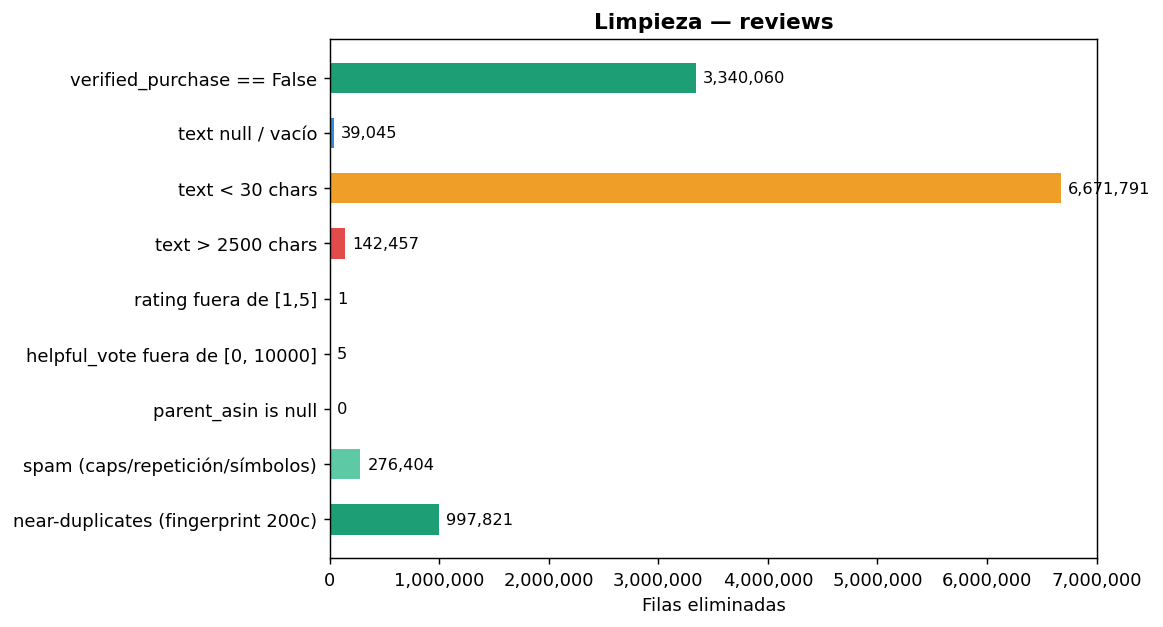


✓ Reviews limpias guardadas


In [ ]:
if CFG.OUT_MERGED.exists() or CFG.OUT_REV.exists():
    if CFG.OUT_MERGED.exists():
        print("✓ merged.parquet existe — skip limpieza reviews")
    else:
        sz = CFG.OUT_REV.stat().st_size/1e9
        print(f"✓ reviews_clean.parquet ya existe ({sz:.2f} GB) — skip")
        print("  Para reejecutar la limpieza, borra reviews_clean.parquet.")
else:
    print("="*65)
    print("  LIMPIEZA — REVIEWS")
    print("="*65)

    pq  = CFG.TMP_REV_PQ.resolve().as_posix()
    rpt = CleaningReport("reviews", _N_REV)
    df  = pl.scan_parquet(pq)
    rpt.snap("raw", _N_REV)

    # R1. Drop columnas sin valor predictivo
    print(f"\n[R1] Drop columnas: {CFG.REV_DROP}")
    to_drop = [c for c in CFG.REV_DROP if c in df.columns]
    df = df.drop(to_drop)
    print(f"  Eliminadas: {to_drop}")

    # R2. Drop verified_purchase == False
    print(f"\n[R2] ANTES: {rpt.cur:,} — drop verified_purchase=False")
    n0 = df.select(pl.len()).collect().item()
    df = df.filter(pl.col("verified_purchase") == True)
    n1 = df.select(pl.len()).collect().item()
    rpt.rec("verified_purchase == False", n0-n1, "compra no verificada")

    # R3. text null / vacío
    print(f"\n[R3] ANTES: {rpt.cur:,} — text null / vacío")
    df = df.filter(pl.col("text").is_not_null() & (pl.col("text").str.strip_chars() != ""))
    n2 = df.select(pl.len()).collect().item()
    rpt.rec("text null / vacío", n1-n2)

    # R4. text muy corto
    print(f"\n[R4] ANTES: {rpt.cur:,} — text < {CFG.REV_MIN_CHARS} chars")
    df = df.filter(pl.col("text").str.len_chars() >= CFG.REV_MIN_CHARS)
    n3 = df.select(pl.len()).collect().item()
    rpt.rec(f"text < {CFG.REV_MIN_CHARS} chars", n2-n3, "sin valor NLP")

    # R5. text muy largo
    print(f"\n[R5] ANTES: {rpt.cur:,} — text > {CFG.REV_MAX_CHARS} chars")
    df = df.filter(pl.col("text").str.len_chars() <= CFG.REV_MAX_CHARS)
    n4 = df.select(pl.len()).collect().item()
    rpt.rec(f"text > {CFG.REV_MAX_CHARS} chars", n3-n4, "copypaste/scraping")

    # R6. rating inválido
    print(f"\n[R6] ANTES: {rpt.cur:,} — rating inválido")
    df = df.filter(pl.col("rating").is_not_null() &
                   pl.col("rating").is_between(CFG.REV_RATING_MIN, CFG.REV_RATING_MAX))
    n5 = df.select(pl.len()).collect().item()
    rpt.rec("rating fuera de [1,5]", n4-n5)

    # R7. helpful_vote > 0  (solo reviews con votos útiles)
    print(f"\n[R7] ANTES: {rpt.cur:,} — helpful_vote invalido")
    df = df.filter(pl.col("helpful_vote").is_not_null() &
                   pl.col("helpful_vote").is_between(CFG.REV_HELPFUL_MIN, CFG.REV_HELPFUL_MAX))
    n6 = df.select(pl.len()).collect().item()
    rpt.rec("helpful_vote fuera de [0, 10000]", n5 - n6, "sin votos útiles")

    # R8. parent_asin nulo
    print(f"\n[R8] ANTES: {rpt.cur:,} — parent_asin nulo")
    df = df.filter(pl.col("parent_asin").is_not_null())
    n7 = df.select(pl.len()).collect().item()
    rpt.rec("parent_asin is null", n6 - n7, "sin producto padre")

    # R9. Spam — recolectar en memoria
    print(f"\n[R9] ANTES: {rpt.cur:,} — detectando spam …")
    df_m = df.collect(engine="in-memory")
    n8 = len(df_m)
    df_m = (df_m.with_columns(
                pl.col("text").map_elements(_is_spam, return_dtype=pl.Boolean).alias("_sp"))
               .filter(~pl.col("_sp")).drop("_sp"))
    rpt.rec("spam (caps/repetición/símbolos)", n8-len(df_m))

    # R10. Near-duplicates
    print(f"\n[R10] ANTES: {len(df_m):,} — deduplicando …")
    n9   = len(df_m)
    df_m = (df_m.with_columns(
                pl.col("text").map_elements(_fingerprint, return_dtype=pl.String).alias("_fp"))
               .unique(subset=["_fp"], keep="first").drop("_fp"))
    rpt.rec("near-duplicates (fingerprint 200c)", n9-len(df_m), "copias entre usuarios")

    # R12. Feature engineering
    print("\n[R10] Feature engineering …")
    ts_expr = (pl.from_epoch(pl.col("timestamp").cast(pl.Int64), time_unit="ms").alias("review_date")
               if "timestamp" in df_m.columns else pl.lit(None).alias("review_date"))
    df_m = df_m.with_columns([
        pl.col("text").str.len_chars().alias("text_len"),
        pl.when(pl.col("rating") >= 4.0).then(pl.lit("positive"))
          .when(pl.col("rating") <= 2.0).then(pl.lit("negative"))
          .otherwise(pl.lit("neutral")).alias("sentiment"),
        (pl.col("rating") >= 4.0).alias("is_satisfied"),
        ts_expr,
    ])

    # Guardar
    print(f"\n[R10] Guardando → {CFG.OUT_REV}")
    df_m.write_parquet(CFG.OUT_REV, compression="zstd", row_group_size=100_000, statistics=True)
    print(f"  {CFG.OUT_REV.stat().st_size/1e9:.2f} GB  |  {len(df_m):,} filas  |  {len(df_m.columns)} cols")
    rpt.summary()
    print("\n✓ Reviews limpias guardadas")


Esta es una decisión clave en pipelines de datos a gran escala debido a las limitaciones en hardware, se decidio evitar preprocesamientos innecesarios. Al verificar si ya existen archivos como `merged.parquet` o `reviews_clean.parquet`, se busca preservar recursos computacionales y tiempo de ejecución.

El uso de scan_parquet de Polars refleja una decisión orientada a la optimización del rendimiento, reduciendo el consumo de memoria y mejorando el tiempo de procesamiento, lo cual es especialmente importante cuando se manejan grandes volúmenes de información.

La eliminación de columnas en la etapa R1 buscar reducir ruido y dimensionalidad. En R2, al filtrar únicamente las reviews con `verified_purchase == True`, se prioriza la calidad y confiabilidad de los datos. Las reseñas no verificadas pueden incluir opiniones falsas, manipuladas o generadas sin una experiencia real con el producto. 

Las etapas R3 y R4 (eliminación de textos nulos, vacíos o demasiado cortos) están orientadas a garantizar que cada registro tenga contenido semántico suficiente. Por otro lado, R5 elimina textos excesivamente largos, lo cual responde a la necesidad de controlar casos de copypaste, scraping o contenido anómalo. Textos muy extensos pueden no representar opiniones genuinas y además incrementan el costo computacional en procesamiento de lenguaje natural, afectando tanto la eficiencia como la calidad del análisis.

El filtrado de ratings inválidos en R6 asegura la consistencia del dominio de datos. Al limitar los valores a un rango esperado (por ejemplo, de 1 a 5), se evita trabajar con datos corruptos o mal formateados que podrían distorsionar análisis estadísticos o modelos predictivos. En R7, la decisión de considerar únicamente reviews con valores válidos de helpful_vote introduce un criterio de relevancia. La validación de parent_asin en R8 garantiza la integridad relacional del dataset. Sin este identificador, la review pierde su conexión con el producto, lo que dificulta análisis posteriores como agrupaciones, recomendaciones o joins con otros datasets.

En R9, la detección de spam implica una decisión más sofisticada, se recolectan los datos en memoria para aplicar funciones personalizadas que identifican patrones sospechosos (uso excesivo de mayúsculas, repetición o símbolos). Esto responde a la necesidad de limpiar ruido no estructurado que no puede detectarse con simples filtros, mejorando significativamente la calidad del texto para análisis posteriores.

La eliminación de near-duplicates en R10 mediante fingerprinting busca evitar la redundancia de información. Reviews muy similares pueden inflar artificialmente ciertas opiniones y sesgar modelos o métricas. Al mantener solo una instancia representativa, se conserva la diversidad del dataset.

Finalmente, la etapa de feature engineering transforma los datos en variables más útiles para análisis y modelado. La creación de métricas como longitud del texto, clasificación de sentimiento o indicadores binarios permite extraer información estructurada a partir de datos no estructurados. Esto es fundamental para alimentar modelos de machine learning o generar insights analíticos de forma más efectiva.


## 7 · EDA Reviews — después de limpiar
Mismas métricas sobre el dataset limpio para comparar.

[EDA REVIEWS POST-LIMPIEZA]  fuente: reviews_clean.parquet


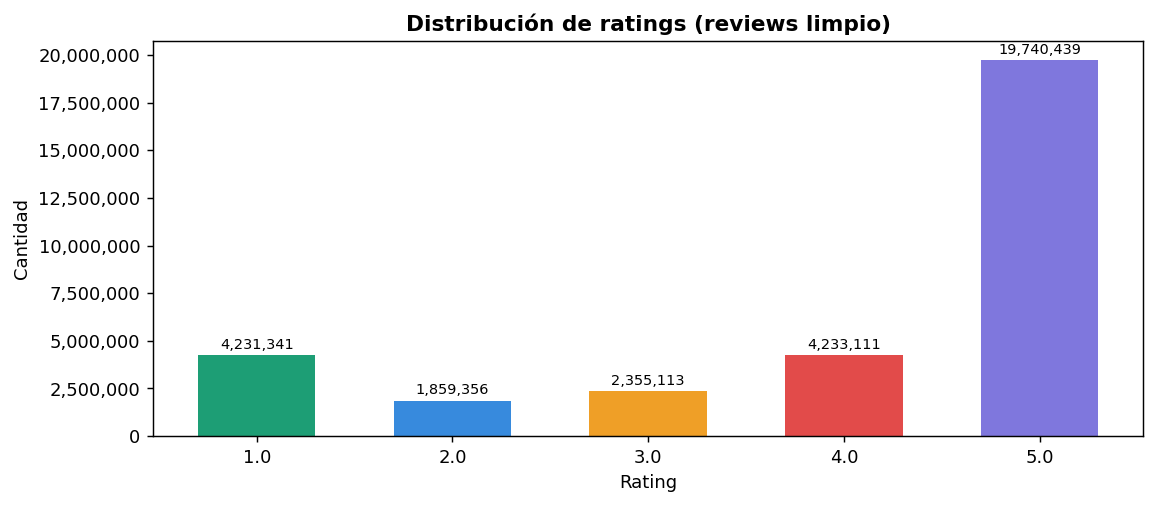

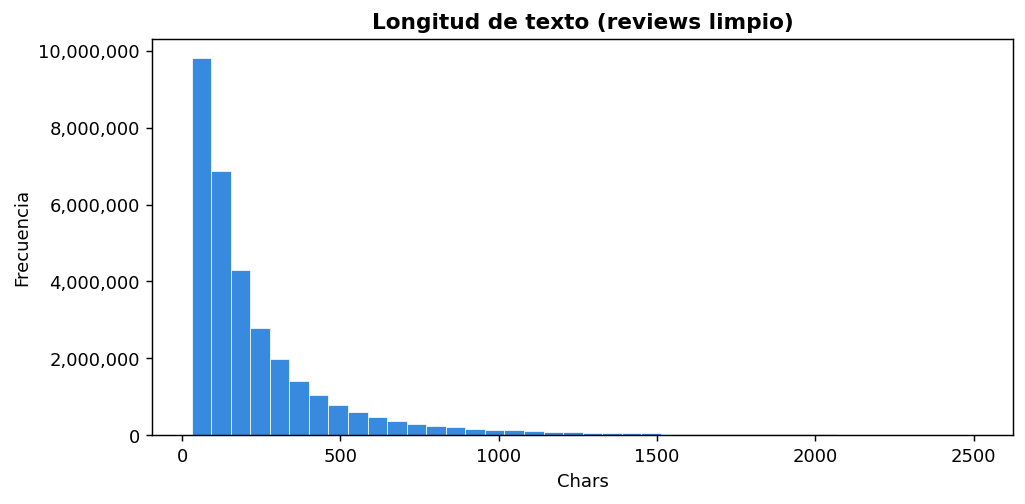

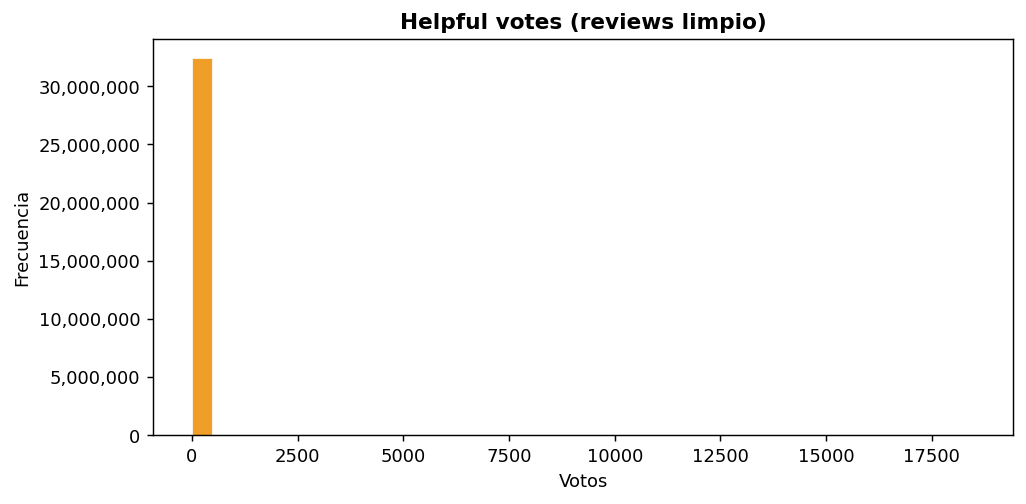

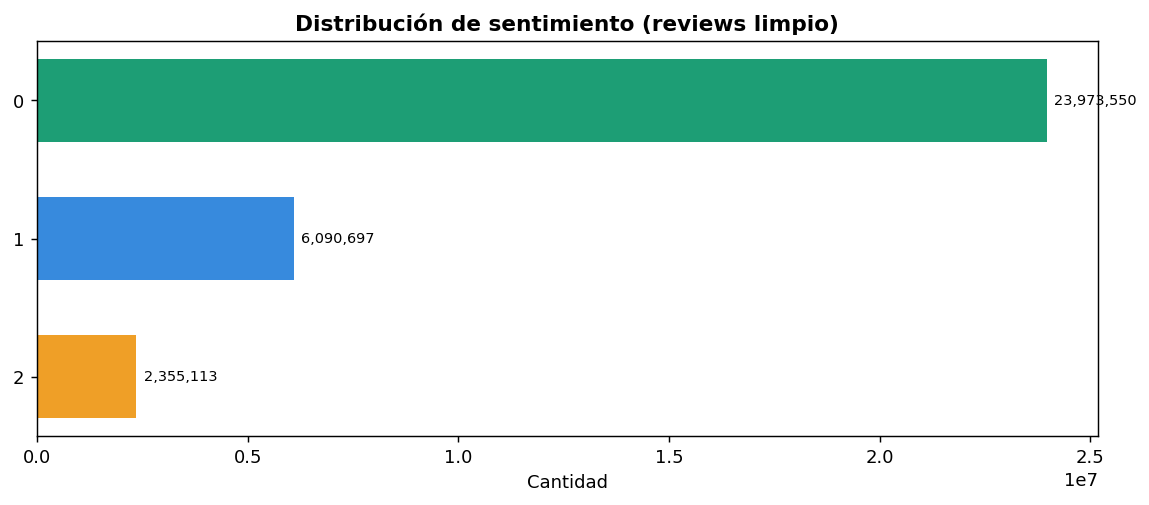

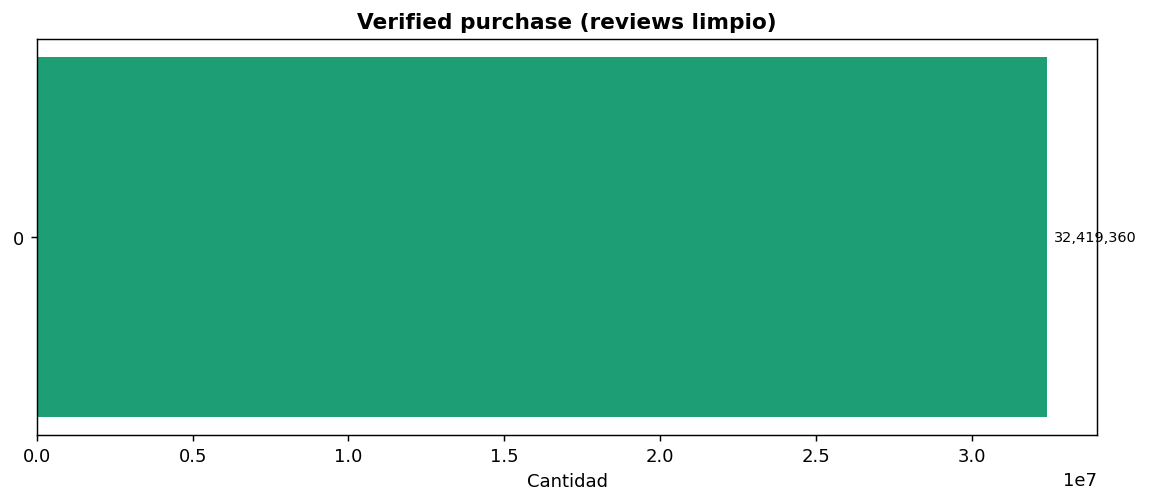


Estadísticas — reviews limpias:


statistic,rating,text_len,helpful_vote
str,f64,f64,f64
"""count""",3.241936e7,3.241936e7,3.241936e7
"""null_count""",0.0,0.0,0.0
"""mean""",4.03,244.661993,1.021503
"""std""",1.443862,284.71298,14.901373
"""min""",1.0,30.0,0.0
"""25%""",3.0,78.0,0.0
"""50%""",5.0,148.0,0.0
"""75%""",5.0,292.0,0.0
"""max""",5.0,2500.0,18501.0


In [ ]:
if not CFG.OUT_REV.exists():
    print("ℹ  reviews_clean.parquet no existe aún. Ejecutá la celda 6 primero.")
else:
    print(f"[EDA REVIEWS POST-LIMPIEZA]  fuente: {CFG.OUT_REV.name}")
    _s = pl.scan_parquet(CFG.OUT_REV.resolve().as_posix()).select([
        pl.col("rating"), pl.col("text_len"), pl.col("helpful_vote"),
        pl.col("verified_purchase"), pl.col("sentiment"),
    ]).collect(engine="in-memory")

    rat = _s.group_by("rating").agg(pl.len().alias("n")).sort("rating")
    plot_bar([str(r) for r in rat["rating"].to_list()], rat["n"].to_list(),
             "Distribución de ratings (reviews limpio)", "Rating", "Cantidad",
             "eda_rev_post_ratings.png")

    plot_hist(_s["text_len"], "Longitud de texto (reviews limpio)", "Chars",
              "eda_rev_post_text_len.png")

    plot_hist(_s["helpful_vote"].drop_nulls(), "Helpful votes (reviews limpio)", "Votos",
              "eda_rev_post_helpful.png", color='#EF9F27')

    sent = _s.group_by("sentiment").agg(pl.len().alias("n")).sort("n", descending=True)
    plot_bar(sent["sentiment"].to_list(), sent["n"].to_list(),
             "Distribución de sentimiento (reviews limpio)", "Sentimiento", "Cantidad",
             "eda_rev_post_sentiment.png", horizontal=True)

    vp = _s["verified_purchase"].value_counts().sort("verified_purchase")
    plot_bar([str(v) for v in vp["verified_purchase"].to_list()],
             vp["count"].to_list(),
             "Verified purchase (reviews limpio)", "Verificado", "Cantidad",
             "eda_rev_post_verified.png", horizontal=True)

    print("\nEstadísticas — reviews limpias:")
    display(_s[["rating","text_len","helpful_vote"]].describe())


**OBSERVACIONES**
1. Quedaron 33,693,585 del total que habia en un principio, la columna que vio su numero mas disminuido fue la de reviews positivas, esto, dado que los dos filtros que mas filas borraron fueron los de menos de 30 char en el reviews y los que no tiene una compra comprobada, por lo cual se puede inferir que muchos de estos eran spam y/o no aportaban mucho al dataset en general
2. Se puede observar que la longitud del texto media es de 200 char lo cual hace que cada review aporte un valor unico al modelo, o al menos eso se espera luego del filtrado.
3. No se observa una diferencia notable respecto a como se encontraba antes, solamente que a pesar que el tope es de 30000  la review con mas votos apenas llega a la mitad, por lo cual no hay muchos valores que indiquen que las reviews fueron utiles
4. Como era de esperarse, al crear una nueva columna de sentimiento, positivo, negativo y neutral, la columna de positivo es la que mas registros tienen debido a que la columna de rating 5 es la que mas registros tiene, seguido de la columna de negativo y por ultimo la columna de neutral
5. Este grafico se encuentra mas que todo para la comprobacion de que ya no existen reviews con compras no verificadas, lo cual se comprueba en el grafico
6. Por ultimo en el resumen podemos observar algunas cosas, rating ya no tiene dos reviews con cero lo cual comprueba de que nuestro filtrafo fue correcto, ademas la media aun indica que la mayoria de datos estan acumulados en un rating de cinco ya que desde el 50% todos los datos tienen rating 5. Por otra parte podemos observar que la longitud maxima de una review esta en el tope que marcamos de 2500 char, la media se encuentra en los 148 char lo que es un valor adecuado para una review, por otra parte ya no hay review vacias, sin texto las cuales no sirven a los objetivos de este proyecto por lo cual comprobamos que el filtraod funciono. Por ultimo, en la columna de helpful_votes se pude observar que ya no hay filas con valores invalidos (negativos), ademas de que existe un valor maximo de 18501 reviews positivas, pero la media se encuentra en 1 por lo cual la mayoria de reseñas no tienen ninguna valoración por parte de otros usuarios.

## 8 · EDA Metadata — antes de limpiar

[EDA METADATA PRE-LIMPIEZA]  fuente: meta_raw.parquet


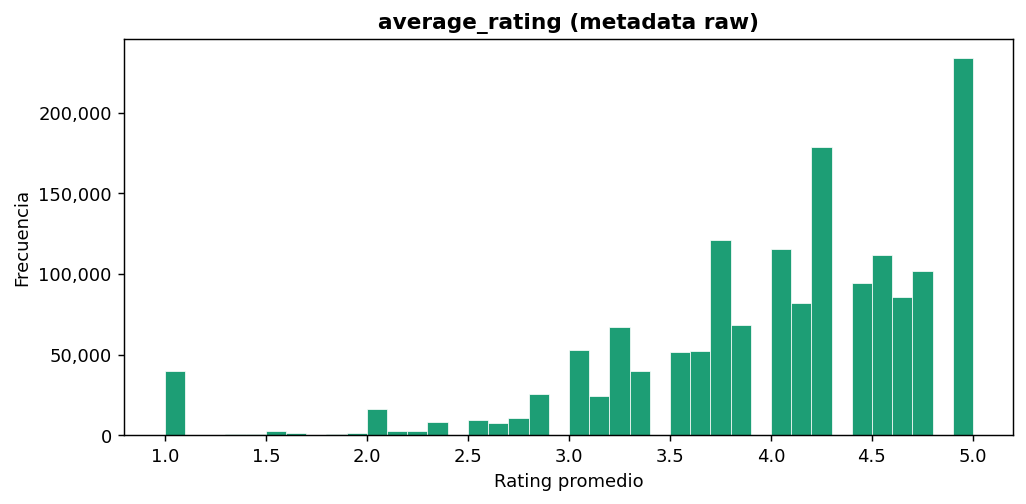

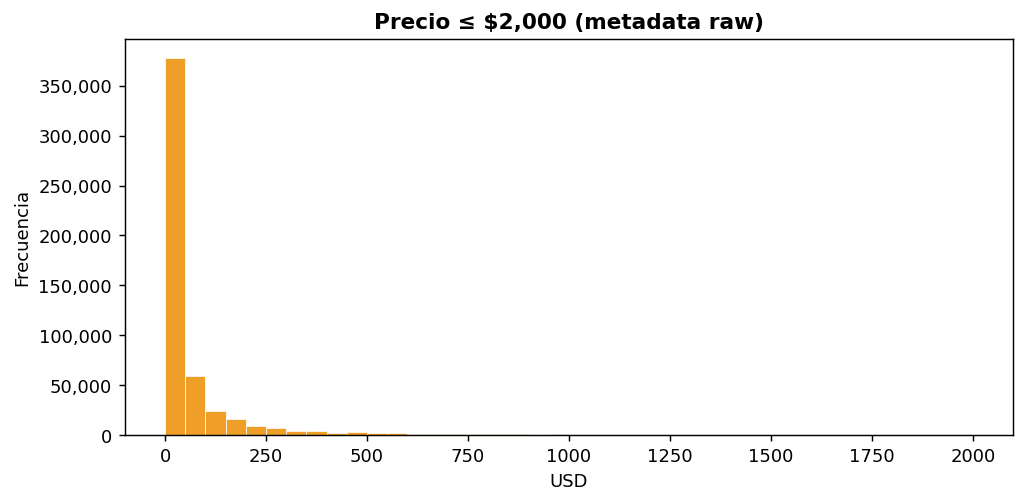

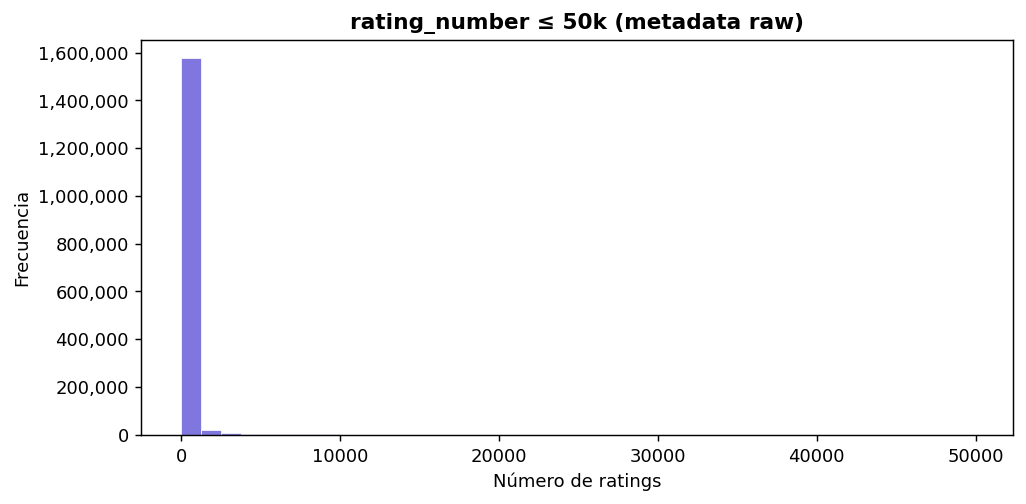

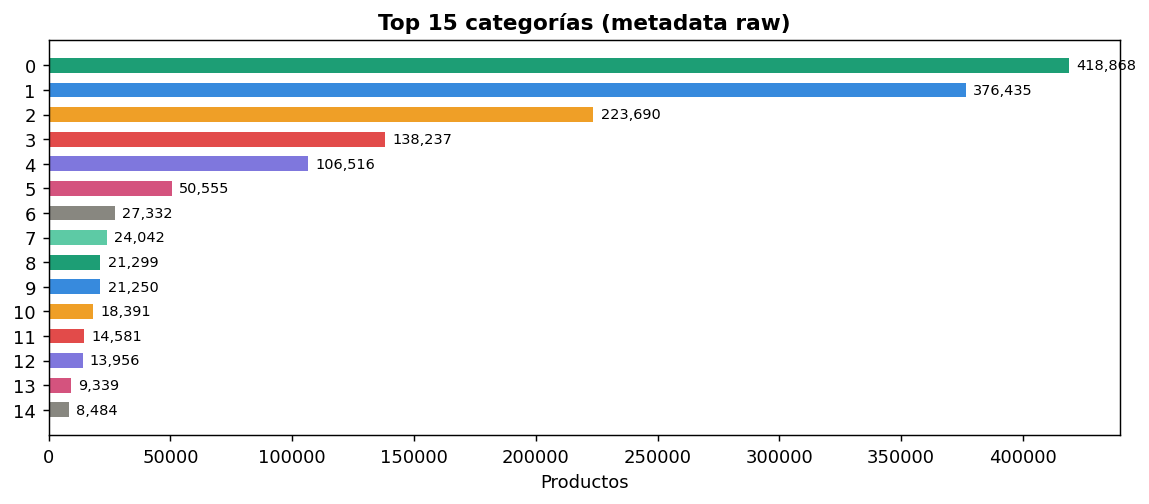


Estadísticas — metadata raw:


statistic,average_rating,rating_number,price
str,f64,f64,f64
"""count""",1.610012e6,1.610012e6,526449.0
"""null_count""",0.0,0.0,1.083563e6
"""mean""",4.008541,180.483308,96.457675
"""std""",0.833138,2543.980066,319.173788
"""min""",1.0,1.0,0.0
"""25%""",3.6,3.0,11.99
"""50%""",4.2,12.0,22.9
"""75%""",4.6,49.0,60.0
"""max""",5.0,1.034896e6,44630.0


In [ ]:
if CFG.OUT_MERGED.exists() and not CFG.TMP_META_PQ.exists():
    print("ℹ  merged.parquet ya existe y no hay parquet tmp — EDA pre no disponible.")
else:
    _src_meta = ( CFG.TMP_META_PQ if CFG.TMP_META_PQ.exists() else None)
    if _src_meta is None:
        print("ℹ  No hay datos de metadata disponibles. Ejecutá las celdas 3 y 4 primero.")
    else:
        print(f"[EDA METADATA PRE-LIMPIEZA]  fuente: {_src_meta.name}")
        _sm = pl.scan_parquet(_src_meta.resolve().as_posix()).select([
            pl.col("average_rating"), pl.col("rating_number"),
            pl.col("price"), pl.col("main_category"),
        ]).collect(engine="in-memory")

        plot_hist(_sm["average_rating"].drop_nulls(),
                  "average_rating (metadata raw)", "Rating promedio",
                  "eda_meta_pre_avg_rating.png", color='#1D9E75')

        _pv = _sm["price"].drop_nulls()
        _pv = _pv.filter(_pv <= 2000)
        plot_hist(_pv, "Precio ≤ $2,000 (metadata raw)", "USD",
                  "eda_meta_pre_price.png", color='#EF9F27')

        _rn = _sm["rating_number"].drop_nulls()
        _rn = _rn.filter(_rn <= 50_000)
        plot_hist(_rn, "rating_number ≤ 50k (metadata raw)", "Número de ratings",
                  "eda_meta_pre_rating_number.png", color='#7F77DD')

        cat = (_sm.filter(pl.col("main_category").is_not_null())
                  .group_by("main_category").agg(pl.len().alias("n"))
                  .sort("n", descending=True).head(15))
        plot_bar(cat["main_category"].to_list(), cat["n"].to_list(),
                 "Top 15 categorías (metadata raw)", "Categoría", "Productos",
                 "eda_meta_pre_categories.png", horizontal=True)

        print("\nEstadísticas — metadata raw:")
        display(_sm[["average_rating","rating_number","price"]].describe())


**OBSERVACIONES**
1. Al igual que los metadatos, la media del rating tiende a ir al 5, con muy pocos datos mientras mas bajo es el average, lo que nos da certeza de que estos datos estan relacionados al tener una similitud con el comportamiento de las reviews, donde varias tendian a tener un valor de 5
2. En este grafico se puede observar que el precio de los productos obtenidos es de menos de 250 dolares en su gran mayoría, por lo cual no hay productos demasiado caros o que esten muy fuera de un producto normal, son productos de compra común
3. En este grafico se muestra la cantidad de reviews el numero de ratings en el producto, se puede observar que ningun producto cuenta con demasiadas, existen casi 2 millones de metadatos y el dataset de reviews original es de 43 millones aproximadamente, entonces se observa que existen numeros no tan altos de reviews por producto, ninguna esta acumulada en un solo producto
4. Se observa que las categorias no estan sumamente divididas, en la metadata, casi un tercio esta en una sola categoría, pero luego va rebajando uniformemente, esta informacion por ahora no es relevante ya que sabemos que hay muchos productos en una categoria pero no sabemos cuantas reviews de productos hay de las categorias, pos las distribuciones es probable de que se mantenga asi, pero es mejor verlo luego del merge
5. En la columna de average rating se puede observar que hay una gran cantidad de reseñas en 5, la media de las reseñas es de 5 como se pudo observar antes en otro grafico, por otra parte, el rating_number tiene algunos outliers, con el valor mas resaltante el de 1 millon de reviews en un producto, este se conservara debido al valor prodictivo que pueda llegar a tener. Por ultimo, se tiene una alarmante cantidad de nulos en el precio, el precio mas alto llega a los 44k pero el quartil superior nos indica que todos estan acumulados por debajo de los 120 dolares aprox. se hará un análisis de la columna de price para determinar su tratamiento.

In [ ]:
src = (CFG.TMP_META_PQ if CFG.TMP_META_PQ.exists() 
       else None)

if src is None:
    print("No hay archivo de metadata")
else:
    print("="*80)
    print("ANÁLISIS DETALLADO DE CATEGORÍAS Y PRECIO")
    print("="*80)

    # Cargamos solo las columnas necesarias para ahorrar memoria
    df = pl.scan_parquet(src).select(
        ["main_category", "categories", "price"]
    ).collect()

    total = len(df)
    print(f"\nTotal filas : {total:,}\n")

    # ANÁLISIS DE main_category 
    print("1. VALORES EN 'main_category'")
    print("-" * 50)
    print(df["main_category"].value_counts(sort=True))

    # ANÁLISIS DE categories (primer nivel) 
    print("\n\n2. PRIMER NIVEL DE 'categories' (top_category)")
    print("-" * 60)

    df = df.with_columns(
        pl.col("categories")
          .list.first()
          .str.strip_chars()
          .fill_null("Sin categoría")
          .alias("top_category")
    )

    print(df["top_category"].value_counts(sort=True).head(20))   # Muestra las 20 más frecuentes

    # ANÁLISIS DETALLADO DE 'price'
    print("\n\n3. ANÁLISIS DETALLADO DE LA COLUMNA 'price'")
    print("-" * 60)

    nulos = df.select(pl.col("price").is_null().sum()).item()
    
    print(f"price is_null()  : {nulos:,}  ({nulos/total*100:.1f}%)")
    print(f"price no nulo    : {total - nulos:,}  ({(total-nulos)/total*100:.1f}%)")
    
    # Distribución de precios (top 10 valores más comunes)
    print("\nDistribución de valores en 'price' (top 10):")
    print(df["price"].value_counts(sort=True).head(10))
    
    # Valores sospechosos (por si acaso)
    print("\nValores especiales (como string o mal parseados):")
    special = df.filter(pl.col("price").is_not_null()).filter(
        (pl.col("price").cast(pl.Utf8).str.strip_chars() == "") |
        (pl.col("price").cast(pl.Utf8).str.to_lowercase().is_in(["none", "n/a", "null", ""]))
    )
    print(f"Filas con valores sospechosos como '', 'none', 'N/A': {len(special)}")
    
    # Estadísticas solo de precios válidos
    print("\nEstadísticas de precios NO nulos:")
    stats = df.filter(pl.col("price").is_not_null())["price"].describe()
    print(stats)

    # PRECIOS NULOS POR CATEGORÍA
    print("\n\n4. PRECIOS NULOS POR CATEGORÍA (top 15)")
    print("-" * 50)
    
    nulls_by_cat = (
        df.group_by(["main_category", "top_category"])
        .agg([
            pl.count().alias("total"),
            pl.col("price").is_null().sum().alias("nulos_price"),
            (pl.col("price").is_null().sum() / pl.count() * 100).round(1).alias("%_nulos")
        ])
        .sort("%_nulos", descending=True)
        .head(30)
    )
    print(nulls_by_cat)

ANÁLISIS DETALLADO DE CATEGORÍAS Y PRECIO

Total filas : 1,610,012

1. VALORES EN 'main_category'
--------------------------------------------------
shape: (43, 2)
┌───────────────────────────┬────────┐
│ main_category             ┆ count  │
│ ---                       ┆ ---    │
│ str                       ┆ u32    │
╞═══════════════════════════╪════════╡
│ Computers                 ┆ 418868 │
│ All Electronics           ┆ 376435 │
│ Camera & Photo            ┆ 223690 │
│ Cell Phones & Accessories ┆ 138237 │
│ Home Audio & Theater      ┆ 106516 │
│ …                         ┆ …      │
│ Digital Music             ┆ 3      │
│ Magazine Subscriptions    ┆ 2      │
│ Audible Audiobooks        ┆ 1      │
│ Unique Finds              ┆ 1      │
│ Collectibles & Fine Art   ┆ 1      │
└───────────────────────────┴────────┘


2. PRIMER NIVEL DE 'categories' (top_category)
------------------------------------------------------------
shape: (4, 2)
┌──────────────────────────────┬─────────┐
│ top_

El primer paso, donde se seleccionan únicamente las columnas main_category, categories y price, responde a una decisión de eficiencia y enfoque analítico. En lugar de cargar todo el dataset (más de 1.6 millones de filas), se limita el análisis a variables relevantes para entender la estructura del catálogo y el comportamiento del precio. En el análisis de main_category, se observa una distribución altamente desbalanceada: categorías como Computers (418,868) y All Electronics (376,435) dominan el dataset, mientras que otras apenas tienen 1 o 2 registros. Esto justifica una decisión importante las categorías con muy baja frecuencia no son estadísticamente representativas, por lo que podrían eliminarse o agruparse en una categoría “otros” para evitar ruido y problemas en modelos de ML.

El análisis de top_category (primer nivel de categories) nos dice que esta no es muy relevante ya que hay una gran cantidad sin primera categoria, asi que es mejor guiarse por la main_category. El análisis de la columna price es probablemente el más crítico. Se observa que el 67.3% de los precios son nulos, lo cual es extremadamente alto. Esto justifica decisiones fuertes en el pipeline, como la es imputar valores. El hecho de que solo el 32.7% tenga valores válidos indica que el precio no es una variable confiable en su estado actual y que cualquier modelo que dependa de ella podría verse seriamente afectado por sesgos o falta de información.

La distribución de precios muestra valores típicos como 9.99, 19.99, etc., lo cual es consistente con estrategias de pricing psicológico en e-commerce. Esto valida que los datos tienen coherencia en los valores no nulos. Sin embargo, las estadísticas revelan algo más profundo: una media de 96.45 con una desviación estándar de 319.17 y un máximo de 44,630 indica una distribución altamente sesgada con outliers extremos. Esto justifica aplicar transformaciones como logaritmos, winsorización o eliminación de outliers antes de usar esta variable en modelos.

El valor mínimo de 0.0 también es relevante. Puede representar productos gratuitos, errores de carga o placeholders, por lo que requiere validación adicional. Dependiendo del contexto, podría eliminarse o tratarse como dato faltante encubierto.

El análisis de valores “especiales” en price (como strings vacíos o “N/A”) muestra que no existen casos de este tipo, lo cual es una señal positiva: indica que el proceso de ingestión o parseo fue correcto y que no hay errores evidentes de tipo de dato en esta columna.

Finalmente, el análisis de precios nulos por categoría aporta una visión clave: hay categorías con 100% de valores nulos, aunque muchas tienen muy pocas filas (lo que limita su relevancia). Sin embargo, también hay categorías grandes con porcentajes altos de nulos, como All Electronics – Sin categoría con 85.2%. Esto sugiere que la ausencia de precio no es aleatoria, sino que depende de la categoría, lo cual es crucial.

## 9 · Limpieza Metadata
Pasos en orden:
1. Drop `images`, `videos`, `store`, `bought_together`,`subtitle`, `author`
2. Filtrar `parent_asin` nulo (sin llave de join)
3. Filtrar `title` nulo / vacío
4. Filtrar `average_rating` fuera de [1, 5]
5. Filtrar `price` inválido
6. Deduplicar por `parent_asin` (mantener el más popular)
7. limpiar columnas anidadas
8. Aplicar estrategia de imputacion de `price`


  LIMPIEZA — METADATA
  ── [raw] 1,610,012 filas (100.0% del original)
  Cols seguras  : 6  → ['main_category', 'title', 'average_rating', 'rating_number', 'price', 'parent_asin']
  Cols anidadas : ['features', 'description', 'images', 'videos', 'categories', 'details', 'bought_together']

[M1] Drop columnas: ['images', 'videos', 'store', 'bought_together', 'subtitle', 'author'] — excluidas del scan

[M2] ANTES: 1,610,012 — parent_asin nulo
  ✓  [parent_asin nulo                            ]  -        0 ( 0.00%)  → 1,610,012

[M3] ANTES: 1,610,012 — title nulo / vacío
  ✓  [title nulo / vacío                          ]  -       94 ( 0.01%)  → 1,609,918

[M4] ANTES: 1,609,918 — average_rating inválido
  ✓  [average_rating fuera de [1,5]               ]  -        0 ( 0.00%)  → 1,609,918

[M5] ANTES: 1,609,918 — price inválido
  ✓  [price fuera de [$0.01,$50000]               ]  -       10 ( 0.00%)  → 1,609,908

  Recolectando columnas seguras...
  1,609,908 filas válidas tras filtros M2-

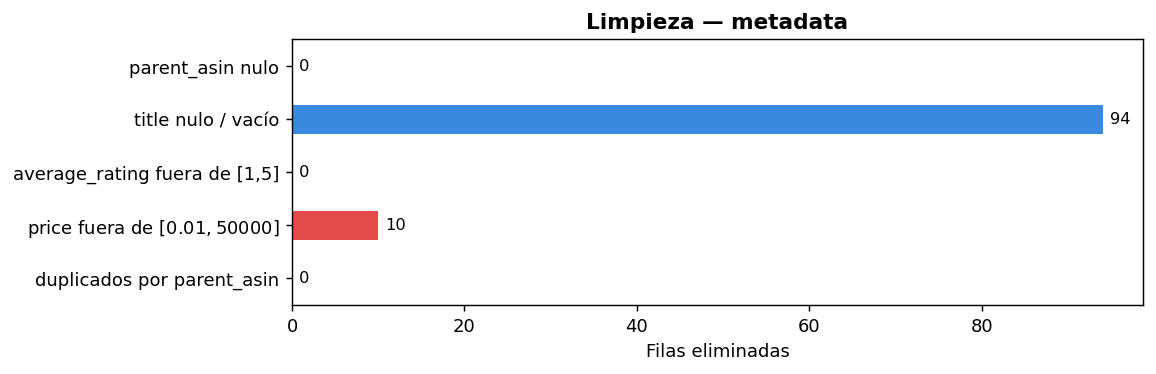


✓ Metadata limpia guardada


In [16]:
if CFG.OUT_MERGED.exists() or CFG.OUT_META.exists():
    if CFG.OUT_MERGED.exists():
        print("✓ merged.parquet existe — skip limpieza metadata")
    else:
        sz = CFG.OUT_META.stat().st_size/1e9
        print(f"✓ meta_clean.parquet ya existe ({sz:.2f} GB) — skip")
        print("  Para reejecutar, borrá meta_clean.parquet.")
else:
    
    print("="*65)
    print("  LIMPIEZA — METADATA")
    print("="*65)

    pq  = CFG.TMP_META_PQ.resolve().as_posix()
    rpt = CleaningReport("metadata", _N_META)
    rpt.snap("raw", _N_META)

    # Separar columnas seguras vs anidadas DESDE EL INICIO 
    NESTED_COLS = ["features", "description", "images", "videos",
                   "categories", "details", "bought_together"]

    full_schema = pl.read_parquet_schema(pq)
    safe_cols = [c for c in full_schema if c not in NESTED_COLS
                                              and c not in CFG.META_DROP]
    nested_present = [c for c in NESTED_COLS if c in full_schema]

    print(f"  Cols seguras  : {len(safe_cols)}  → {safe_cols}")
    print(f"  Cols anidadas : {nested_present}")

    # Leer columnas seguras como LazyFrame (sin columnas Map/List problemáticas)
    df = pl.scan_parquet(pq, hive_partitioning=False).select(safe_cols)

    # M1. Drop columnas (ya excluidas del scan, solo informar)
    print(f"\n[M1] Drop columnas: {CFG.META_DROP} — excluidas del scan")

    # M2. parent_asin null 
    print(f"\n[M2] ANTES: {rpt.cur:,} — parent_asin nulo")
    n0 = df.select(pl.len()).collect().item()
    df = df.filter(pl.col("parent_asin").is_not_null())
    n1 = df.select(pl.len()).collect().item()
    rpt.rec("parent_asin nulo", n0-n1, "sin llave de join")

    # M3. title nulo 
    print(f"\n[M3] ANTES: {rpt.cur:,} — title nulo / vacío")
    df = df.filter(pl.col("title").is_not_null() & (pl.col("title").str.strip_chars() != ""))
    n2 = df.select(pl.len()).collect().item()
    rpt.rec("title nulo / vacío", n1-n2)

    # M4. average_rating inválido
    print(f"\n[M4] ANTES: {rpt.cur:,} — average_rating inválido")
    df = df.filter(pl.col("average_rating").is_null() |
                   pl.col("average_rating").is_between(1.0, 5.0))
    n3 = df.select(pl.len()).collect().item()
    rpt.rec("average_rating fuera de [1,5]", n2-n3)

    # M5. price inválido 
    print(f"\n[M5] ANTES: {rpt.cur:,} — price inválido")
    df = df.filter(pl.col("price").is_null() |
                   pl.col("price").is_between(CFG.META_PRICE_MIN, CFG.META_PRICE_MAX))
    n4 = df.select(pl.len()).collect().item()
    rpt.rec(f"price fuera de [${CFG.META_PRICE_MIN:.2f},${CFG.META_PRICE_MAX:.0f}]",
            n3-n4, "precios negativos o absurdos")

    # Materializar columnas seguras 
    print("\n  Recolectando columnas seguras...")
    df_safe = df.collect()
    # Guardar índice de parent_asin válidos para filtrar columnas anidadas
    valid_asins = set(df_safe["parent_asin"].to_list())
    print(f"  {len(df_safe):,} filas válidas tras filtros M2-M5")

    # Leer columnas anidadas con PyArrow
    cols_to_read = ["parent_asin"] + nested_present
    pa_table = pq_arrow.read_table(pq, columns=cols_to_read)

    # Castear Extension types → pa.string() columna por columna
    clean_arrays = []
    clean_names = []

    for i in range(pa_table.num_columns):
        name = pa_table.schema.field(i).name
        arr = pa_table.column(i).combine_chunks()

        if name == "parent_asin":
            # No tocar, ya es string limpio
            clean_arrays.append(arr.cast(pa.string()))
        else:
            py_list = arr.to_pylist()
            clean_arrays.append(
                pa.array(
                    [json.dumps(v, ensure_ascii=False) if v is not None and not isinstance(v, str) else v
                    for v in py_list],
                    type=pa.string()
                )
            )
        clean_names.append(name)

    # Construir tabla con schema 100% limpio (solo pa.string)
    pa_table = pa.table(
        {name: arr for name, arr in zip(clean_names, clean_arrays)},
        schema=pa.schema([(name, pa.string()) for name in clean_names])
    )

    nested_df = pl.from_arrow(pa_table)
    del pa_table


    # Filtrar solo las filas que pasaron M2-M5
    nested_df = nested_df.filter(pl.col("parent_asin").is_in(list(valid_asins)))

    # Castear cada columna anidada a String de forma segura
    safe_nested = {"parent_asin": nested_df["parent_asin"]}
    for col in nested_present:
        try:
            safe_nested[col] = nested_df[col].cast(pl.String, strict=False)
        except Exception:
            print(f"  ⚠ '{col}' — cast falló, serializando con json.dumps...")
            safe_nested[col] = pl.Series(
                col,
                [json.dumps(v, ensure_ascii=False) if v is not None else "[]"
                 for v in nested_df[col].to_list()]
            )
    nested_pl = pl.DataFrame(safe_nested)
    del nested_df

    # Join: seguras + anidadas (por parent_asin para alinear filas) 
    df_full = df_safe.join(nested_pl, on="parent_asin", how="left")
    del df_safe, nested_pl
    print(f"  df_full: {len(df_full):,} filas × {len(df_full.columns)} cols")

    # M6. Deduplicar por parent_asin 
    print(f"\n[M6] ANTES: {len(df_full):,} — deduplicando por parent_asin")
    n_before = len(df_full)
    df_m = (df_full
            .sort("rating_number", descending=True, nulls_last=True)
            .unique(subset=["parent_asin"], keep="first"))
    del df_full
    rpt.rec("duplicados por parent_asin", n_before - len(df_m), "se mantiene el más popular")

    # M7. Limpiar columnas anidadas
    print("\n[M7] Limpiando columnas list/dict …")
    for col in ["features", "description", "categories", "details"]:
        df_m = _clean_list_col(df_m, col)
    df_m = df_m.with_columns(pl.col("rating_number").fill_null(0))

    # M8. Imputar price con mediana
    if "price" in df_m.columns and df_m["price"].null_count() > 0:
        n_nulos = df_m["price"].null_count()
        print(f"\n[M8] Imputando {n_nulos:,} precios nulos ({n_nulos/len(df_m)*100:.1f}%)...")

        df_m = df_m.with_columns(
            pl.col("price").is_null().cast(pl.Int8).alias("price_imputed")
        )

        medians_fine = (
            df_m
            .group_by(["main_category"])
            .agg(
                pl.col("price").drop_nulls().median().alias("med_fine"),
                pl.col("price").drop_nulls().count().alias("n_fine"),
            )
        )
        medians_cat = (
            df_m
            .group_by("main_category")
            .agg(pl.col("price").drop_nulls().median().alias("med_cat"))
        )
        global_med = df_m["price"].drop_nulls().median()

        df_m = (
            df_m
            .join(medians_fine, on="main_category", how="left")
            .join(medians_cat, on="main_category", how="left")
            .with_columns(
                pl.coalesce([
                    pl.col("price"),
                    pl.when(pl.col("n_fine") >= 10)
                      .then(pl.col("med_fine"))
                      .otherwise(None),
                    pl.col("med_cat"),
                    pl.lit(global_med),
                ]).alias("price")
            )
            .drop("med_fine", "n_fine", "med_cat")
        )
        print(
            f" ✓ Precios imputados jerárquicamente:\n"
            f"    · Nivel 1 → mediana por (main_category) si n >= 10\n"
            f"    · Nivel 2 → mediana por main_category\n"
            f"    · Nivel 3 → mediana global (fallback = ${global_med:.2f})\n"
            f" ✓ Columna 'price_imputed' agregada (0 = real, 1 = imputado)"
        )

    # Guardar 
    print(f"\n[Guardar] → {CFG.OUT_META}")
    df_m.write_parquet(CFG.OUT_META, compression="zstd", row_group_size=50_000, statistics=True)
    print(f"  {CFG.OUT_META.stat().st_size/1e9:.2f} GB  |  {len(df_m):,} filas  |  {len(df_m.columns)} cols")
    rpt.summary()
    print("\n✓ Metadata limpia guardada")

Al inicio, se repite la misma lógica vista antes, verificar si ya existen archivos procesados (merged.parquet o meta_clean.parquet). Esto responde a una decisión de optimización del pipeline, evitando reprocesar datos pesados innecesariamente.

Una de las decisiones más importantes ocurre al separar columnas “seguras” de columnas anidadas. Las columnas anidadas (listas, diccionarios, estructuras complejas como features, images, categories) suelen generar problemas en procesamiento masivo, especialmente al trabajar con Polars, ya que complican el tipado, el rendimiento y la serialización. Los pasos M2 a M5 corresponden a filtros de calidad básicos pero críticos. El control sobre average_rating dentro del rango [1,5] asegura consistencia semántica, evitando valores corruptos o fuera de dominio. De forma similar, el filtrado de price dentro de un rango definido elimina valores absurdos (negativos o extremadamente altos), que podrían distorsionar análisis estadísticos o modelos.

Una vez filtradas las columnas seguras, se materializan en memoria y se obtiene el conjunto de parent_asin válidos. Esto permite un paso clave: sincronizar las columnas anidadas con los datos ya limpios. Aquí se utiliza Apache Arrow para leer estas columnas complejas, ya que ofrece mejor compatibilidad con estructuras anidadas. El proceso de conversión de estas columnas a strings mediante json.dumps es una decisión estratégica: en lugar de mantener estructuras complejas, se serializan a texto para garantizar compatibilidad, evitar errores de tipo y facilitar almacenamiento en formatos como Parquet. Esto sacrifica algo de estructura, pero gana en robustez y simplicidad para análisis posteriores.

En M6 se eliminan duplicados por parent_asin, lo cual es fundamental porque cada producto debería estar representado una sola vez. En M7 se realiza limpieza adicional sobre columnas anidadas, transformando listas o estructuras en formatos más manejables. Esto apunta a mejorar la calidad del texto y evitar inconsistencias internas dentro de cada campo.

El paso M8, de imputación de precios, es una de las decisiones más importantes del pipeline. Dado que muchos valores de price son nulos, se implementa una estrategia jerárquica:

Primero, se intenta imputar con la mediana dentro de la categoría si hay suficientes datos (n ≥ 10), lo cual asegura cierta robustez estadística. Si no hay suficientes datos, se usa la mediana de la categoría general. Como último recurso, se utiliza la mediana global.

## 10 · EDA Metadata — después de limpiar

[EDA METADATA POST-LIMPIEZA]  fuente: meta_clean.parquet


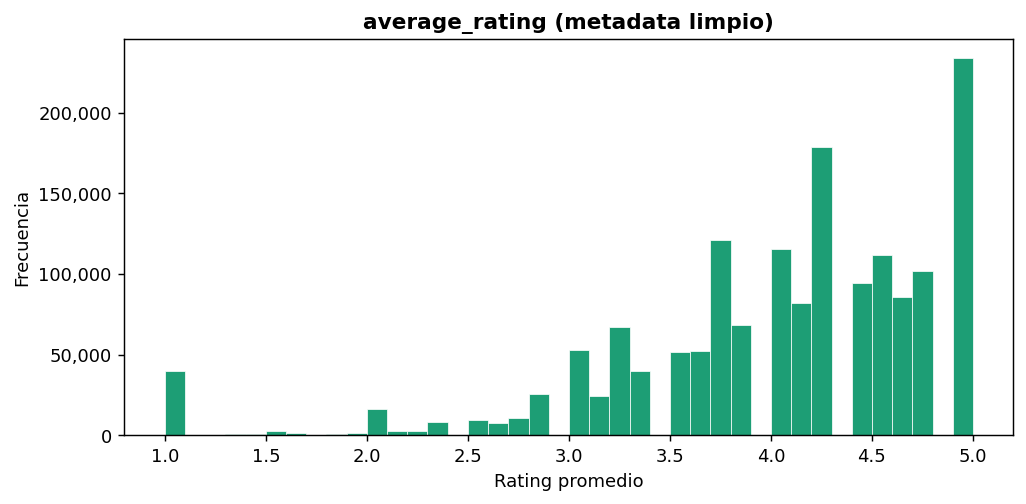

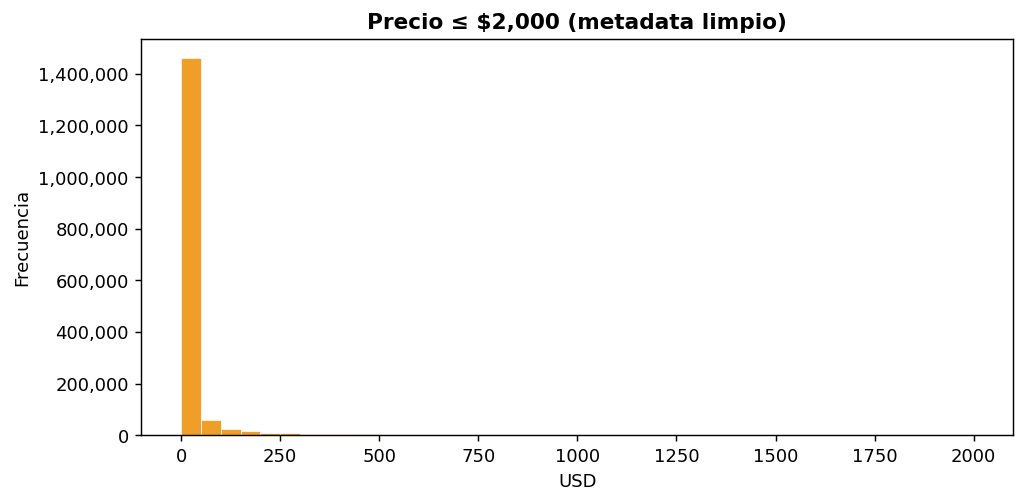

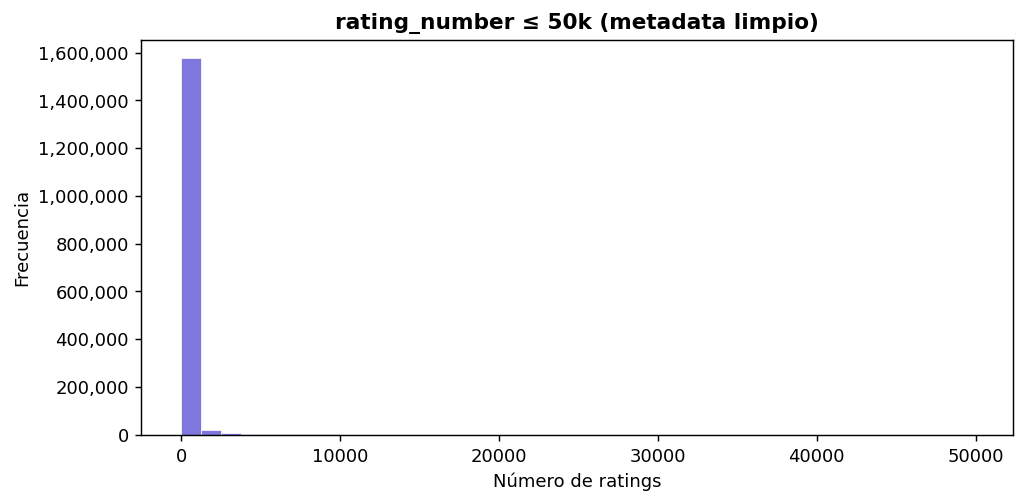

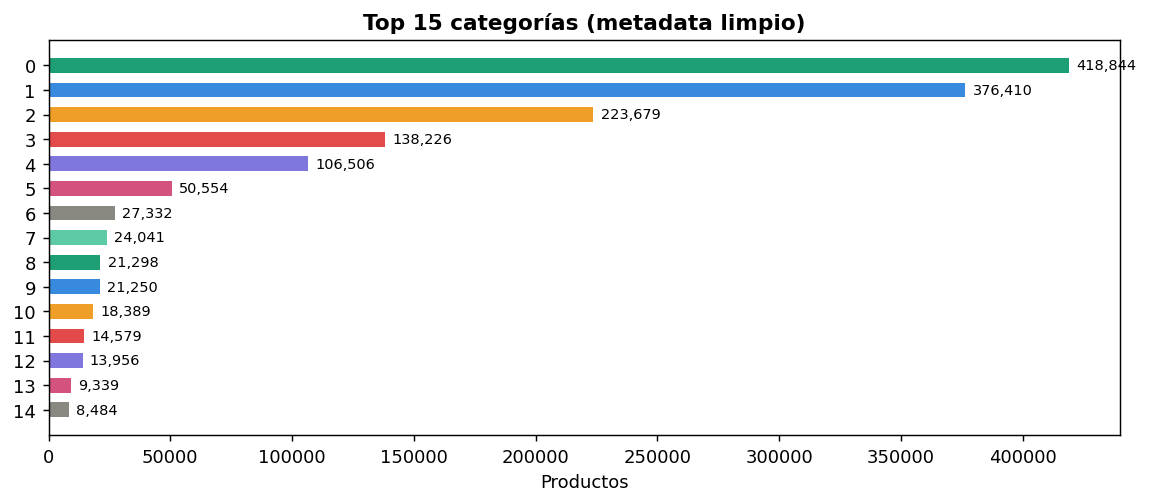


Estadísticas — metadata limpia:


statistic,average_rating,rating_number,price
str,f64,f64,f64
"""count""",1.609908e6,1.609908e6,1.609908e6
"""null_count""",0.0,0.0,0.0
"""mean""",4.008545,180.490863,48.184817
"""std""",0.833136,2544.061751,185.669588
"""min""",1.0,1.0,0.01
"""25%""",3.6,3.0,19.99
"""50%""",4.2,12.0,22.9
"""75%""",4.6,49.0,30.38
"""max""",5.0,1.034896e6,44630.0


In [18]:
if not CFG.OUT_META.exists():
    print("ℹ  meta_clean.parquet no existe aún. Ejecutá la celda 9 primero.")
else:
    print(f"[EDA METADATA POST-LIMPIEZA]  fuente: {CFG.OUT_META.name}")
    _sm = pl.scan_parquet(CFG.OUT_META.resolve().as_posix()).select([
        pl.col("average_rating"), pl.col("rating_number"),
        pl.col("price"), pl.col("main_category"),
    ]).collect(engine="in-memory")

    plot_hist(_sm["average_rating"].drop_nulls(),
              "average_rating (metadata limpio)", "Rating promedio",
              "eda_meta_post_avg_rating.png", color='#1D9E75')

    _pv2 = _sm["price"].drop_nulls()
    _pv2 = _pv2.filter(_pv2 <= 2000)
    plot_hist(_pv2, "Precio ≤ $2,000 (metadata limpio)", "USD",
              "eda_meta_post_price.png", color='#EF9F27')

    _rn2 = _sm["rating_number"].drop_nulls()
    _rn2 = _rn2.filter(_rn2 <= 50_000)
    plot_hist(_rn2, "rating_number ≤ 50k (metadata limpio)", "Número de ratings",
              "eda_meta_post_rating_number.png", color='#7F77DD')

    cat2 = (_sm.filter(pl.col("main_category").is_not_null())
               .group_by("main_category").agg(pl.len().alias("n"))
               .sort("n", descending=True).head(15))
    plot_bar(cat2["main_category"].to_list(), cat2["n"].to_list(),
             "Top 15 categorías (metadata limpio)", "Categoría", "Productos",
             "eda_meta_post_categories.png", horizontal=True)

    print("\nEstadísticas — metadata limpia:")
    display(_sm[["average_rating","rating_number","price"]].describe())


Por la poca eliminacion de filas, se puede observar que no existen muchos cambios entre los resultados de los graficos antes y despues de aplicar la limpieza de los datos

## 11 · EDA pre-merge — cobertura del join
Análisis de solapamiento por `parent_asin` antes de ejecutar el join.

[EDA PRE-MERGE]
  parent_asin únicos — Reviews  : 1,413,150
  parent_asin únicos — Metadata : 1,609,908
  En ambos (inner join)         : 1,413,061  (100.0% de reviews)
  Solo en reviews               : 89  (se perderán en inner join)
  Solo en metadata              : 196,847


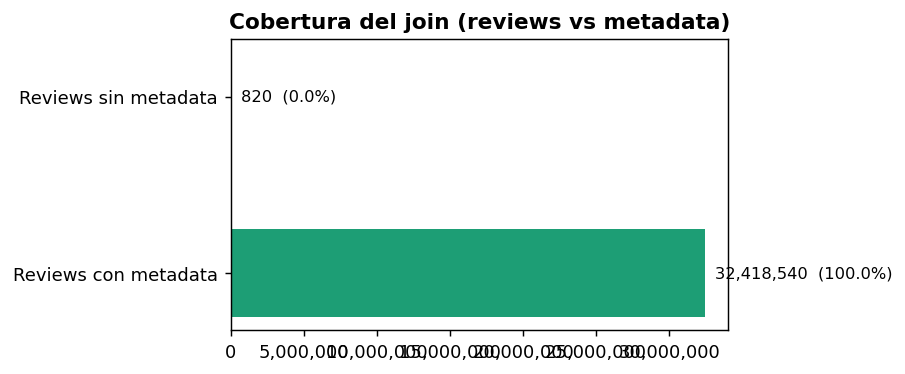

In [ ]:
if not CFG.OUT_REV.exists() or not CFG.OUT_META.exists():
    print("ℹ  Se necesitan reviews_clean.parquet y meta_clean.parquet.")
    print("   Ejecuta las celdas 6 y 9 primero.")
else:
    print("[EDA PRE-MERGE]")
    _rev_pm  = pl.scan_parquet(CFG.OUT_REV.resolve().as_posix()).select("parent_asin").collect()
    _meta_pm = pl.scan_parquet(CFG.OUT_META.resolve().as_posix()).select("parent_asin").collect()

    rev_asin  = set(_rev_pm["parent_asin"].drop_nulls().to_list())
    meta_asin = set(_meta_pm["parent_asin"].drop_nulls().to_list())
    overlap   = rev_asin & meta_asin
    only_rev  = rev_asin - meta_asin
    only_meta = meta_asin - rev_asin

    print(f"  parent_asin únicos — Reviews  : {len(rev_asin):,}")
    print(f"  parent_asin únicos — Metadata : {len(meta_asin):,}")
    print(f"  En ambos (inner join) : {len(overlap):,}  ({len(overlap)/max(len(rev_asin),1)*100:.1f}% de reviews)")
    print(f"  Solo en reviews  : {len(only_rev):,}  (se perderán en inner join)")
    print(f"  Solo en metadata  : {len(only_meta):,}")

    # Cuántas reseñas tendrán metadata
    _n_with = _rev_pm.filter(pl.col("parent_asin").is_in(list(overlap))).shape[0]
    _n_rev_total = _rev_pm.shape[0]
    _n_without = _n_rev_total - _n_with

    fig, ax = plt.subplots(figsize=(7,3))
    labels = ['Reviews con metadata','Reviews sin metadata']
    vals   = [_n_with, _n_without]
    bars   = ax.barh(labels, vals, color=[PAL[0],PAL[3]], height=0.5)
    ax.bar_label(bars, labels=[f'{v:,}  ({v/_n_rev_total*100:.1f}%)' for v in vals],
                 padding=6, fontsize=9)
    ax.set_title("Cobertura del join (reviews vs metadata)", fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
    plt.tight_layout()
    path = CFG.REPORTS / "eda_premerge_coverage.png"
    fig.savefig(path, dpi=130, bbox_inches='tight'); plt.close(fig)
    display(Image(str(path), width=700))


Este bloque realiza una validación previa al merge entre los datasets de reviews y metadata, asegurando que ambos archivos existen y que pueden combinarse correctamente. Para ello, extrae únicamente la columna parent_asin y compara los valores únicos usando conjuntos, lo que permite medir cuántos registros coinciden entre ambos datasets y cuántos quedarían fuera en un join. Esto se hace de forma eficiente usando Polars, evitando cargar datos innecesarios en memoria.

Los resultados muestran que prácticamente todas las reviews tienen metadata asociada (solo 89 casos sin match), lo que justifica usar un inner join sin pérdida significativa de información. Además, se genera un gráfico que visualiza esta cobertura, confirmando que el merge será confiable y representativo, y evitando incluir productos sin reviews que no aportan valor al análisis.

## 12 · Merge Reviews ↔ Metadata
Inner join por `parent_asin`. Skip si `merged.parquet` ya existe.

In [9]:
# VER COLUMNAS DE META
_meta_df_temp_xyz123 = pl.scan_parquet(CFG.OUT_META.resolve().as_posix())

print("COLUMNAS de meta_clean.parquet:")
for i, col in enumerate(_meta_df_temp_xyz123.collect_schema().names(), 1):
    print(f"   {i:2d}. {col}")

print(f"\nTotal de columnas: {len(_meta_df_temp_xyz123.collect_schema())}")

COLUMNAS de meta_clean.parquet:
    1. main_category
    2. title
    3. average_rating
    4. rating_number
    5. price
    6. parent_asin
    7. features
    8. description
    9. images
   10. videos
   11. categories
   12. details
   13. bought_together
   14. price_imputed

Total de columnas: 14


Se usa esta parte del código para verificar que variables aun se encuentran en el archivo meta, para filtrar cuales deberian quedarse y cuales no

In [ ]:
if CFG.OUT_MERGED.exists():
    print(f"✓ merged.parquet ya existe ({CFG.OUT_MERGED.stat().st_size/1e9:.2f} GB) — cargando")
    df_merged = pl.scan_parquet(CFG.OUT_MERGED)  # no carga en RAM
    print("Cargado como LazyFrame (scan lazy)")
else:
    if not CFG.OUT_REV.exists() or not CFG.OUT_META.exists():
        raise RuntimeError("Faltan reviews_clean.parquet y/o meta_clean.parquet. " "Ejecuta las celdas 6 y 9.")
    # Merge con DuckDB (más eficiente para joins grandes que Polars in-memory)
    con = duckdb.connect()
    con.execute("SET memory_limit='12GB'")
    con.execute("SET threads=8")
    # Definir columnas a seleccionar del metadata (solo las seguras y necesarias para el merge)
    META_COLS = [
        "parent_asin", "main_category", "average_rating",
        "rating_number", "price", "features", "description",
        "details", "price_imputed"
    ]

    available = con.execute(f"""
        SELECT name 
        FROM parquet_schema('{CFG.OUT_META}')
    """).fetchdf()["name"].tolist()

    select_meta   = [c for c in META_COLS if c in available]
    meta_cols_str = ", ".join(select_meta)

    # Separar expresiones de title para cada contexto
    title_inner = ", title"                    if "title" in available else ""
    title_outer = ", m.title AS product_title" if "title" in available else ""

    print("  Ejecutando inner join con DuckDB…")
    # El query hace un inner join entre reviews y metadata usando parent_asin, seleccionando solo las columnas necesarias del metadata
    query = f"""
        COPY (
            SELECT r.*, {meta_cols_str}{title_outer}
            FROM read_parquet('{CFG.OUT_REV}') AS r
            INNER JOIN (
                SELECT {meta_cols_str}{title_inner}
                FROM read_parquet('{CFG.OUT_META}')
            ) AS m
            ON r.parent_asin = m.parent_asin
        )
        TO '{CFG.OUT_MERGED}'
        (FORMAT PARQUET, COMPRESSION 'zstd', ROW_GROUP_SIZE 100000)
    """

    con.execute(query)
    con.close()

    size_gb = CFG.OUT_MERGED.stat().st_size / 1e9
    print(f"  {size_gb:.2f} GB guardados → {CFG.OUT_MERGED}")

    df_merged = pl.scan_parquet(CFG.OUT_MERGED)
    print("\n✓ Merge completo")


✓ merged.parquet ya existe (22.70 GB) — cargando
Cargado como LazyFrame (scan lazy)


Este bloque se encarga de realizar el merge final entre reviews y metadata de forma eficiente y escalable. Primero verifica si el archivo merged.parquet ya existe; si es así, simplemente lo carga en modo lazy usando Polars, evitando cargarlo completamente en memoria. Esto permite trabajar con datasets grandes sin consumir demasiados recursos, manteniendo el pipeline rápido y reutilizable.

Si el archivo no existe, se ejecuta un inner join usando DuckDB, una decisión clave para manejar grandes volúmenes de datos fuera de RAM. Se seleccionan solo columnas relevantes del metadata para reducir el tamaño del resultado y mejorar el rendimiento. El uso de un inner join está previamente justificado por el análisis de cobertura, asegurando que casi todas las reviews tienen metadata asociada. Finalmente, el resultado se guarda en formato Parquet comprimido (zstd), optimizando espacio y velocidad de lectura, y quedando listo para análisis o modelado posterior.

## 13 · EDA post-merge
Distribuciones sobre el dataset merged. Ejecutable de forma independiente.

[EDA POST-MERGE]  32,418,540 filas × 20 cols


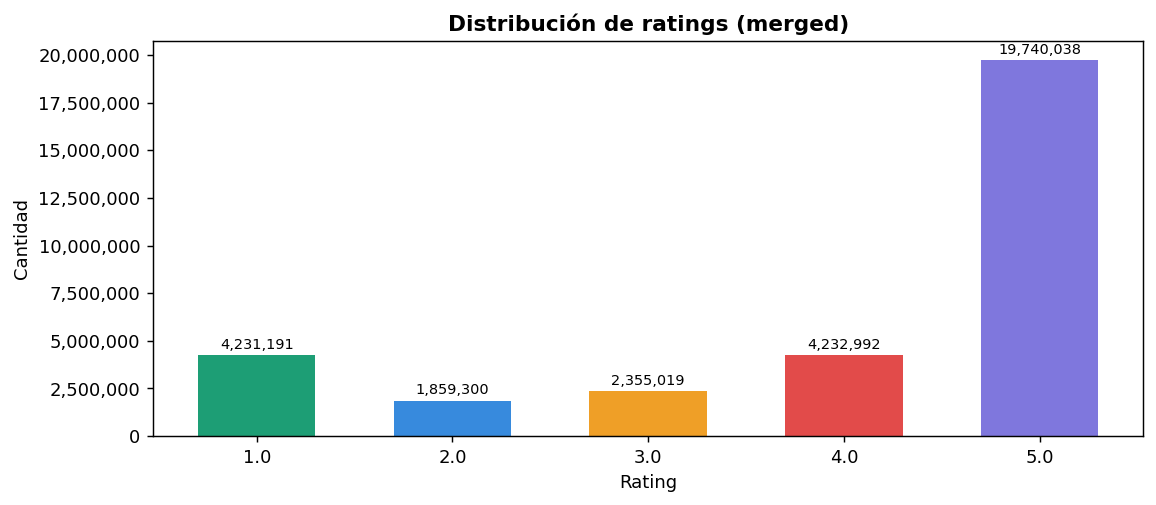

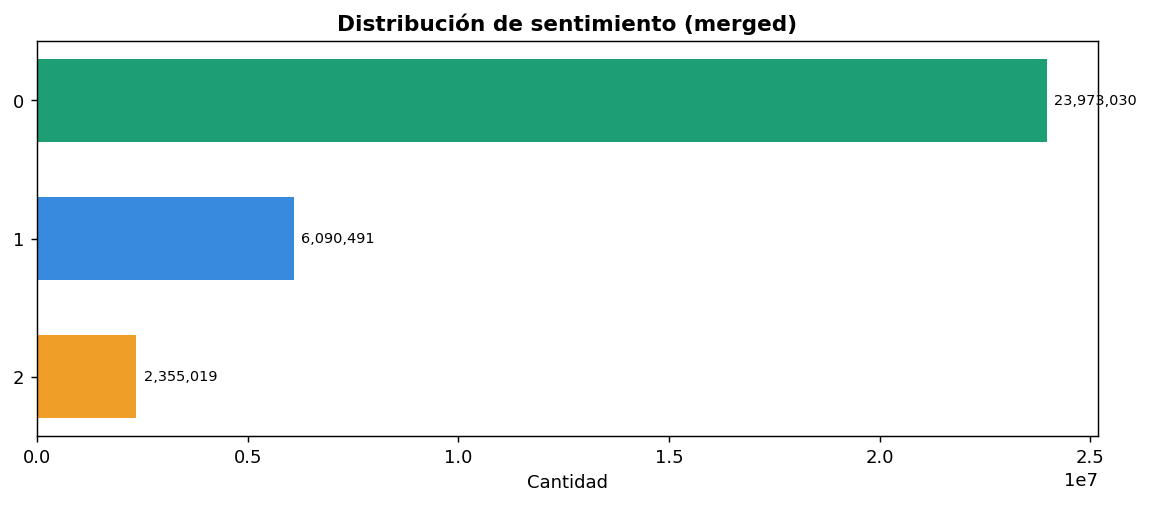

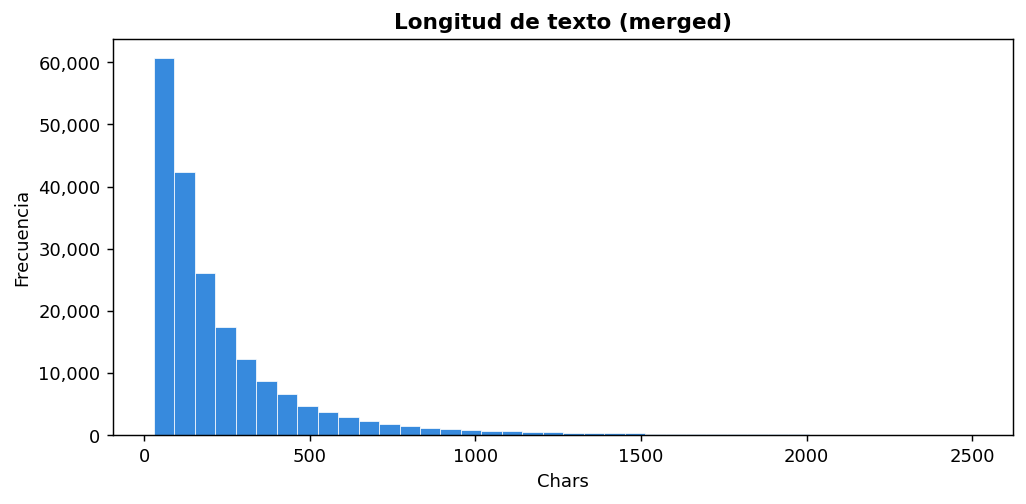

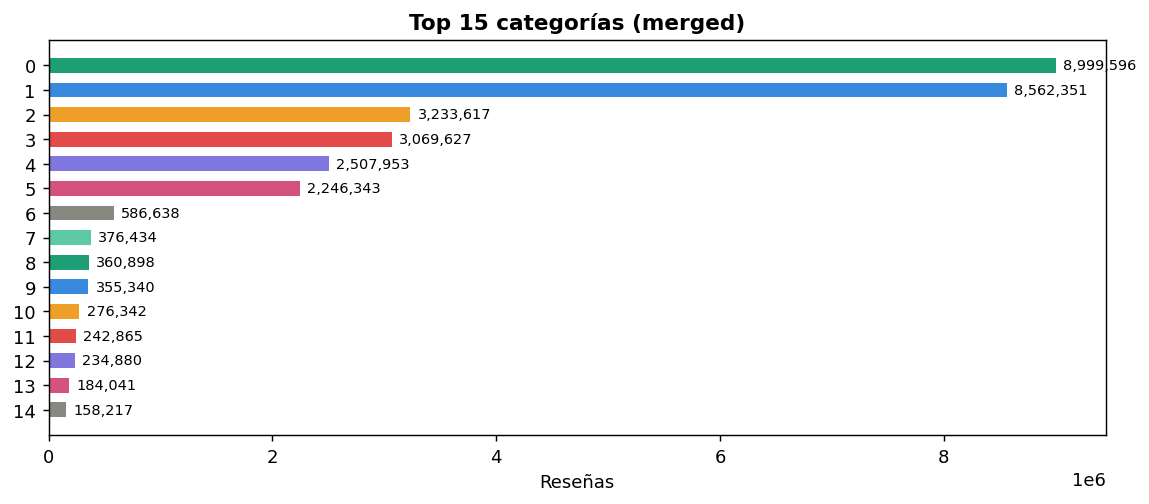

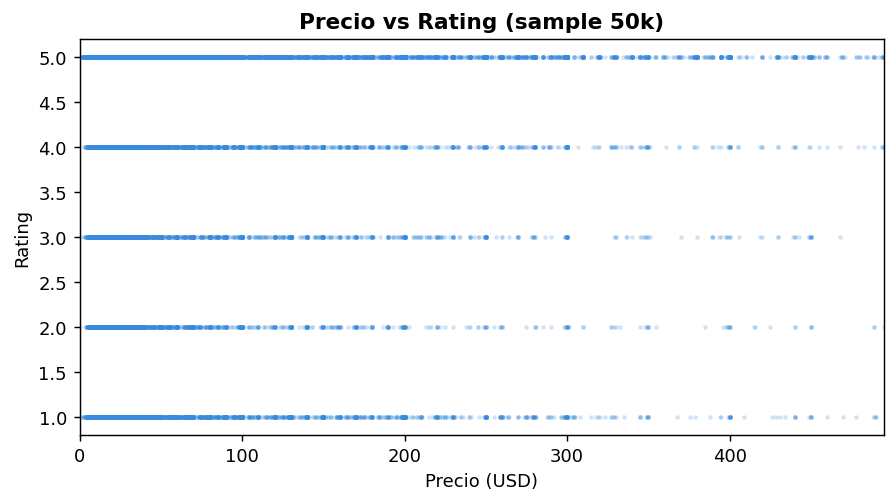

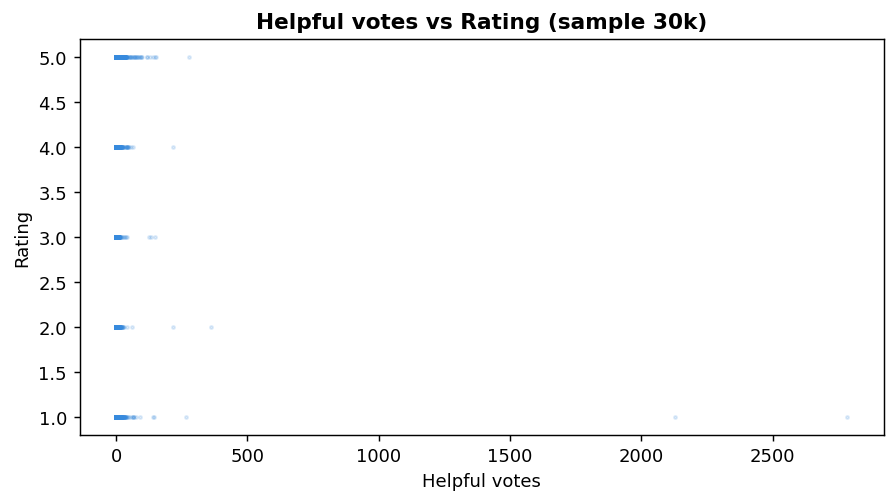

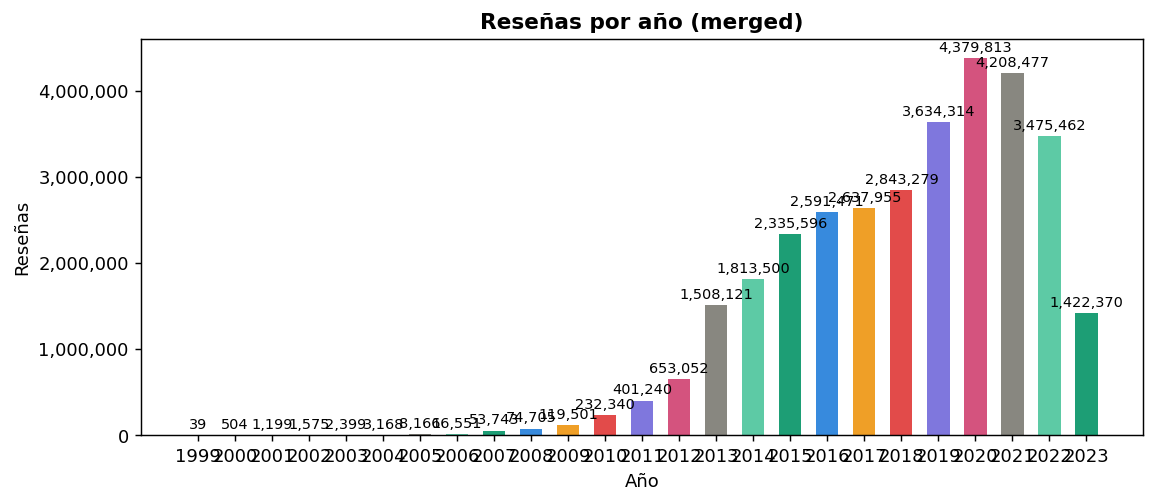


Estadísticas del merged (usando SUMMARIZE):


column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
str,str,str,str,i64,str,str,str,str,str,i64,"decimal[9,2]"
"""rating""","""DOUBLE""","""1.0""","""5.0""",5,"""4.030008939329162""","""1.4438581414998841""","""3.0""","""5.0""","""5.0""",32418540,0.00
"""text_len""","""UINTEGER""","""30""","""2500""",2558,"""244.66194776199052""","""284.71295149386407""","""78""","""148""","""292""",32418540,0.00
"""helpful_vote""","""BIGINT""","""0""","""18501""",1746,"""1.0215093893802745""","""14.901557989091591""","""0""","""0""","""0""",32418540,0.00
"""price""","""DOUBLE""","""0.01""","""24996.99""",22869,"""51.84278126031676""","""129.6936781723273""","""17.628173224670675""","""22.98614619398471""","""35.3590707593061""",32418540,0.00
"""average_rating""","""DOUBLE""","""1.0""","""5.0""",39,"""4.2793162677743455""","""0.4068823037015842""","""4.1""","""4.3999956994484215""","""4.599998200198366""",32418540,0.00


In [12]:
if not CFG.OUT_MERGED.exists():
    print("ℹ  merged.parquet no existe. Ejecutá la celda 12 primero.")
else:
    path = CFG.OUT_MERGED.resolve().as_posix()
    con  = duckdb.connect()

    # Metadata
    total    = con.execute(f"SELECT COUNT(*) FROM read_parquet('{path}')").fetchone()[0]
    all_cols = [r[0] for r in con.execute(f"SELECT * FROM read_parquet('{path}') LIMIT 0").description]
    print(f"[EDA POST-MERGE]  {total:,} filas × {len(all_cols)} cols")

    # 1. Ratings
    rat = con.execute(f"""
        SELECT CAST(rating AS VARCHAR) AS rating, COUNT(*) AS n
        FROM read_parquet('{path}')
        GROUP BY rating ORDER BY rating
    """).pl()
    plot_bar(rat["rating"].to_list(), rat["n"].to_list(),
             "Distribución de ratings (merged)", "Rating", "Cantidad",
             "eda_merged_ratings.png")

    # 2. Sentimiento
    if "sentiment" in all_cols:
        sent = con.execute(f"""
            SELECT sentiment, COUNT(*) AS n
            FROM read_parquet('{path}')
            GROUP BY sentiment ORDER BY n DESC
        """).pl()
        plot_bar(sent["sentiment"].to_list(), sent["n"].to_list(),
                 "Distribución de sentimiento (merged)", "Sentimiento", "Cantidad",
                 "eda_merged_sentiment.png", horizontal=True)

    # 3. Longitud de texto (sample para el histograma)
    tl = con.execute(f"""
        SELECT text_len 
        FROM read_parquet('{path}')
        WHERE text_len IS NOT NULL
        USING SAMPLE 200000 ROWS (reservoir, {SEED})
    """).pl()["text_len"]
    plot_hist(tl, "Longitud de texto (merged)", "Chars", "eda_merged_text_len.png")

    # 4. Top 15 categorías
    if "main_category" in all_cols:
        cat = con.execute(f"""
            SELECT main_category, COUNT(*) AS n
            FROM read_parquet('{path}')
            WHERE main_category IS NOT NULL
            GROUP BY main_category ORDER BY n DESC LIMIT 15
        """).pl()
        plot_bar(cat["main_category"].to_list(), cat["n"].to_list(),
                 "Top 15 categorías (merged)", "Categoría", "Reseñas",
                 "eda_merged_categories.png", horizontal=True)

    # 5. Precio vs Rating
    if "price" in all_cols:
        xlim = con.execute(f"""
            SELECT QUANTILE_CONT(price, 0.99) FROM read_parquet('{path}')
            WHERE price IS NOT NULL
        """).fetchone()[0]
        samp = con.execute(f"""
            SELECT price, rating FROM read_parquet('{path}')
            WHERE price IS NOT NULL
            USING SAMPLE 50000 ROWS (reservoir, {SEED})
        """).pl()
        plot_scatter(samp["price"].to_list(), samp["rating"].to_list(),
                     "Precio vs Rating (sample 50k)", "Precio (USD)", "Rating",
                     "eda_merged_price_vs_rating.png", xlim=float(xlim))

    # 6. helpful_vote vs rating
    samp2 = con.execute(f"""
        SELECT helpful_vote, rating FROM read_parquet('{path}')
        USING SAMPLE 30000 ROWS (reservoir, {SEED})
    """).pl()
    plot_scatter(samp2["helpful_vote"].to_list(), samp2["rating"].to_list(),
                 "Helpful votes vs Rating (sample 30k)", "Helpful votes", "Rating",
                 "eda_merged_helpful_vs_rating.png")

    # 7. Reseñas por año
    if "review_date" in all_cols:
        yrs = con.execute(f"""
            SELECT YEAR(review_date) AS year, COUNT(*) AS n
            FROM read_parquet('{path}')
            WHERE review_date IS NOT NULL
            GROUP BY year ORDER BY year
        """).pl().drop_nulls()
        if len(yrs):
            plot_bar([str(y) for y in yrs["year"].to_list()], yrs["n"].to_list(),
                     "Reseñas por año (merged)", "Año", "Reseñas",
                     "eda_merged_by_year.png")

    # Estadísticas descriptivas
    stat_cols = [c for c in ["rating", "text_len", "helpful_vote", "price", "average_rating"]
                 if c in all_cols]

    # Estadísticas descriptivas - forma más simple y eficiente
    if stat_cols:
        # SUMMARIZE devuelve count, null_percentage, min, max, mean, std, q25, q50, q75, etc.
        stats = con.execute(f"""
            SUMMARIZE SELECT {", ".join(stat_cols)} 
            FROM read_parquet('{path}')
        """).pl()

        print("\nEstadísticas del merged (usando SUMMARIZE):")
        display(stats)

    con.close()


**OBSERVACIONES**
1. Los ratings siguen la tendencia de antes, la mayor cantidad de reviews es positiva, como se observo antes, lo que indica, esto es comun debido a ofertas por una reseña de cinco estrellas, respuestas automatizadas para filtrarlas o promociones por reseñas de cinco estrellas.
2. Para el analisis de sentimiento, se puede observar que al igual que la anterior distribucion, la distribucion de reseñas clasificadas como positivas es mayor, seguida por reseñas negativas y por ultimo las reseñas neutrales, son las que menos representacion tienen.
3. Se puede observar que solo 6 categorias representan la mayor cantidad de reseñas, y las demas categorias quedan en segundo plano o tienen una cantidad de reseñas mucho menor, pero no despreciable, simplemente el porcentaje es mucho mayor.
4. Todas las distribuciones se ven uniformes, excepto en las review de cinco estrellas, donde existe un rango mas alto de reviews, esto debido a que hay una gran cantidad de reseñas por lo que se incluyen muchos productos con precios altos o las reseñas positivas son en su mayoria de productos con precios altos.
5. Se puede observar que la cantidad de votos positivos no es muy alta para los rating de 2-4, pero se puede observar una cantidad algo mayor para los productos con rating de 5 o 1, mostrando que la mayoria de reviews son muy polarizadas.
6. En este ultimo podemos ver que una gran cantidad de reviews vienen de los 202x, tambien se puede identificar la tendencia creciente de reviews mientras los años pasan.
7. La variable rating muestra una distribución discreta entre 1 y 5, con una media de 4.03 y mediana en 5, lo que indica un fuerte sesgo hacia valoraciones positivas. Esto es típico en plataformas de reseñas, donde los usuarios tienden a calificar más cuando están satisfechos.

La variable text_len refleja la longitud de las reseñas, con una media de ~244 caracteres pero una desviación alta (~284), lo que indica gran variabilidad en el tamaño de los textos. El rango (30 a 2500) confirma que ya se aplicaron filtros previos. Esto es relevante en NLP, ya que textos más largos suelen contener más información, pero también aumentan el costo computacional.

En helpful_vote, se observa que la mediana y el percentil 75 son 0, lo que indica que la mayoría de las reviews no reciben votos útiles, mientras que unos pocos casos alcanzan valores muy altos (hasta 18,501). Esto evidencia una distribución altamente sesgada con outliers, lo que sugiere que esta variable podría transformarse (por ejemplo, logarítmicamente) o tratarse como indicador binario (tiene votos vs no tiene).

El price presenta una media de ~51.84 pero con una desviación alta (~129.69) y un máximo cercano a 25,000, lo que indica una distribución muy dispersa con outliers significativos. Los percentiles (Q1 ≈ 17.6, mediana ≈ 22.9, Q3 ≈ 35.3) muestran que la mayoría de productos están en rangos bajos, mientras que unos pocos elevan la media. Esto justifica aplicar transformaciones como log(price) o tratar outliers para evitar que dominen el modelo.

Finalmente, average_rating tiene una media de 4.27 y baja desviación (~0.40), lo que indica que los productos en general están bien valorados y que existe poca variabilidad entre ellos. Esto puede limitar su poder discriminativo como feature, aunque sigue siendo útil como contexto agregado del producto.

## 14 · Análisis de subsampling

In [7]:
# ANÁLISIS DE SUBSAMPLING 
if not CFG.OUT_MERGED.exists():
    print("ℹ  merged.parquet no existe. Ejecutá la celda 12 primero.")
else:
    path = CFG.OUT_MERGED.resolve().as_posix()
    con  = duckdb.connect()

    # Metadata básica
    total = con.execute(f"SELECT COUNT(*) FROM read_parquet('{path}')").fetchone()[0]
    cols  = len(con.execute(f"SELECT * FROM read_parquet('{path}') LIMIT 0").description)

    print("="*65); print("  ANÁLISIS DE SUBSAMPLING"); print("="*65)
    print(f"\nTotal filas: {total:,}   Columnas: {cols}")
    print(f"RAM estimada full (float32): ~{total*cols*4/1e9:.1f} GB")

    # Q1. distribución por rating
    q1 = con.execute(f"""
        SELECT rating, COUNT(*) AS n,
               ROUND(COUNT(*)*100.0/{total}, 2) AS "pct%"
        FROM read_parquet('{path}')
        GROUP BY rating ORDER BY rating
    """).pl()
    print("\nQ1 — Distribución por rating:"); display(q1)

    # Q2. distribución sentimiento
    q2 = con.execute(f"""
        SELECT sentiment, COUNT(*) AS n,
               ROUND(COUNT(*)*100.0/{total}, 2) AS "pct%"
        FROM read_parquet('{path}')
        GROUP BY sentiment ORDER BY n DESC
    """).pl()
    print("\nQ2 — Distribución por sentimiento:"); display(q2)

    # Q3. texto promedio por rating
    q3 = con.execute(f"""
        SELECT rating, ROUND(AVG(text_len), 1) AS avg_text_len
        FROM read_parquet('{path}')
        GROUP BY rating ORDER BY rating
    """).pl()
    print("\nQ3 — Longitud promedio de texto por rating:"); display(q3)

    # Q4. helpful_vote
    hv = con.execute(f"""
        SELECT MEDIAN(helpful_vote)          AS mediana,
               AVG(helpful_vote)             AS media,
               QUANTILE_CONT(helpful_vote, 0.95) AS p95,
               COUNT(*) FILTER (WHERE helpful_vote > 0) AS gt0
        FROM read_parquet('{path}')
    """).fetchone()
    print(f"\nQ4 — Helpful votes:  mediana={hv[0]:.0f}  media={hv[1]:.2f}"
          f"  P95={hv[2]:.0f}  >0={hv[3]:,} ({hv[3]/total*100:.1f}%)")

    # Q5. productos con más reseñas
    q5 = con.execute(f"""
        SELECT parent_asin, COUNT(*) AS n_reviews
        FROM read_parquet('{path}')
        GROUP BY parent_asin ORDER BY n_reviews DESC LIMIT 10
    """).pl()
    print("\nQ5 — Top 10 productos por reseñas:"); display(q5)

    # Q6. distribución por main_category (top 15)
    q6 = con.execute(f"""
        SELECT main_category, COUNT(*) AS n,
        ROUND(COUNT(*)*100.0/{total}, 2) AS "pct%"
        FROM read_parquet('{path}')
        GROUP BY main_category
        ORDER BY n DESC
        LIMIT 15
    """).pl()
    print("\nQ6 — Distribución por main_category (top 15):"); display(q6)

    con.close()


  ANÁLISIS DE SUBSAMPLING

Total filas: 32,418,540   Columnas: 20
RAM estimada full (float32): ~2.6 GB

Q1 — Distribución por rating:


rating,n,pct%
f64,i64,f64
1.0,4231191,13.05
2.0,1859300,5.74
3.0,2355019,7.26
4.0,4232992,13.06
5.0,19740038,60.89



Q2 — Distribución por sentimiento:


sentiment,n,pct%
str,i64,f64
"""positive""",23973030,73.95
"""negative""",6090491,18.79
"""neutral""",2355019,7.26



Q3 — Longitud promedio de texto por rating:


rating,avg_text_len
f64,f64
1.0,258.4
2.0,317.5
3.0,311.1
4.0,303.2
5.0,214.4



Q4 — Helpful votes:  mediana=0  media=1.02  P95=3  >0=7,570,259 (23.4%)

Q5 — Top 10 productos por reseñas:


parent_asin,n_reviews
str,i64
"""B075X8471B""",115155
"""B07GZFM1ZM""",95611
"""B01K8B8YA8""",86818
"""B010BWYDYA""",75271
"""B07H65KP63""",63627
"""B08XPWDSWW""",61754
"""B0791TX5P5""",58925
"""B07S764D9V""",44638
"""B0BW4PFM58""",40954



Q6 — Distribución por main_category (top 15):


main_category,n,pct%
str,i64,f64
"""All Electronics""",8999596,27.76
"""Computers""",8562351,26.41
"""Cell Phones & Accessories""",3233617,9.97
"""Camera & Photo""",3069627,9.47
"""Home Audio & Theater""",2507953,7.74
…,…,…
"""Car Electronics""",355340,1.1
"""Amazon Home""",276342,0.85
"""Apple Products""",242865,0.75


**OBSERVACIONES**

En primer lugar, la distribución de rating evidencia un sesgo fuerte hacia valores altos, la mayoría de las reseñas se concentran en 5 estrellas, seguidas por 4 estrellas, mientras que las calificaciones bajas son minoritarias. Esto indica un claro desbalance de clases, lo que puede hacer que un modelo aprenda a predecir “positivo” por defecto. De forma coherente, la distribución de sentiment refuerza este patrón, con casi tres cuartas partes de los datos etiquetados como positivos.

En la relación entre rating y text_len se observa un comportamiento interesante, las reseñas negativas (ratings bajos) tienden a ser más largas que las positivas. Esto indica que los usuarios insatisfechos suelen argumentar más sus opiniones, mientras que los satisfechos son más breves. Este patrón es relevante porque introduce una señal adicional, ya que la longitud del texto puede actuar como una variable discriminativa.

El análisis de helpful_vote muestra una distribución extremadamente sesgada, la mediana es 0 y la mayoría de las reseñas no reciben votos útiles, mientras que solo un pequeño porcentaje concentra la interacción. Esto indica que la utilidad percibida no es generalizada y que existen pocos casos altamente influyentes. Por ello, esta variable debe tratarse con cuidado, ya sea mediante transformaciones o como indicador binario.

En cuanto a los productos (parent_asin), se observa una concentración fuerte en pocos ítems, donde algunos productos acumulan decenas de miles de reseñas. Esto refleja un fenómeno típico de e-commerce, popularidad desigual, donde pocos productos dominan la atención del usuario. Esto puede sesgar el modelo hacia patrones específicos de esos productos si no se controla mediante subsampling por producto.

Finalmente, la distribución por main_category confirma un sesgo estructural del dataset, unas pocas categorías dominan el volumen total de datos, mientras que otras tienen representación marginal. Por eso, este análisis justifica la necesidad de aplicar estrategias de muestreo estratificado o balanceado.

## 15 · Crear sample estratificado para ML
Stratificado por `rating` (5 clases × per_class filas). Reproducible con `SEED=42`.

Total original : 32,418,540
Ratings únicos : [1.0, 2.0, 3.0, 4.0, 5.0]
Categorías     : 43

Distribución por rating:
  rating=1  n= 4,231,191  (13.1%)
  rating=2  n= 1,859,300  (5.7%)
  rating=3  n= 2,355,019  (7.3%)
  rating=4  n= 4,232,992  (13.1%)
  rating=5  n=19,740,038  (60.9%)

Distribución por categoría:
  All Electronics                           n= 8,999,596  (27.8%)
  Computers                                 n= 8,562,351  (26.4%)
  Cell Phones & Accessories                 n= 3,233,617  (10.0%)
  Camera & Photo                            n= 3,069,627  (9.5%)
  Home Audio & Theater                      n= 2,507,953  (7.7%)
  Amazon Devices                            n= 2,246,343  (6.9%)
  Industrial & Scientific                   n=   586,638  (1.8%)
  __unknown__                               n=   545,480  (1.7%)
  Office Products                           n=   376,434  (1.2%)
  Tools & Home Improvement                  n=   360,898  (1.1%)
  Car Electronics                

rating,n
f64,u32
1.0,148100
2.0,63917
3.0,73599
4.0,128317
5.0,586067



Balance por categoría:


main_category,n
str,u32
"""All Electronics""",277924
"""Computers""",263862
"""Cell Phones & Accessories""",100188
"""Camera & Photo""",94388
"""Home Audio & Theater""",77441
…,…
"""Fire Phone""",20
"""Movies & TV""",2
"""Handmade""",1



Balance por celda (rating × categoría):


rating,main_category,n
f64,str,u32
1.0,null,2535
1.0,"""AMAZON FASHION""",875
1.0,"""All Beauty""",84
1.0,"""All Electronics""",43499
1.0,"""Amazon Devices""",7999
…,…,…
5.0,"""Software""",84
5.0,"""Sports & Outdoors""",3341
5.0,"""Tools & Home Improvement""",6610


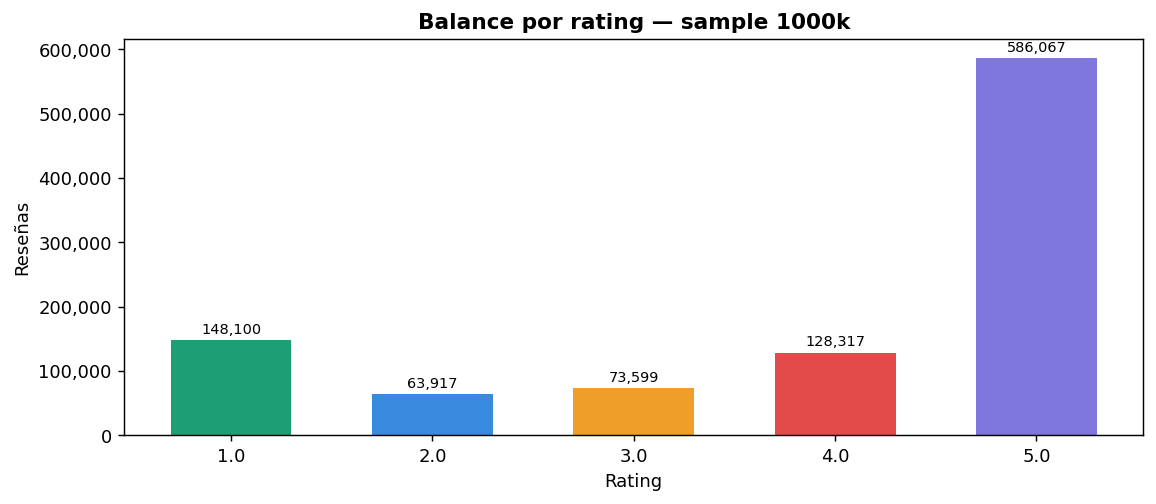

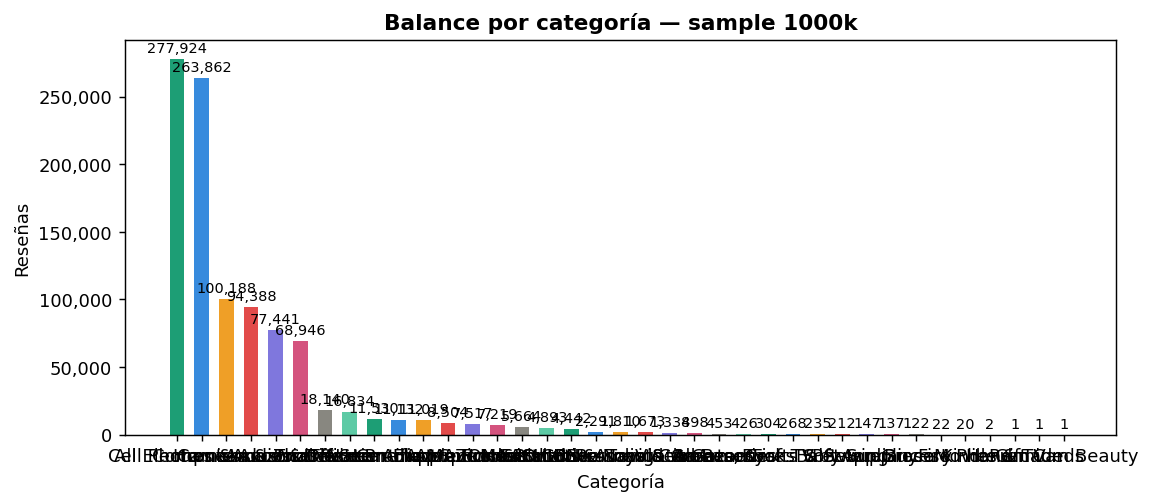


✓ sample_ml.parquet → 703.0 MB  |  1,000,000 filas

Columnas para ML: ['rating', 'title', 'text', 'parent_asin', 'timestamp', 'helpful_vote', 'verified_purchase', 'text_len', 'sentiment', 'is_satisfied', 'review_date', 'main_category', 'average_rating', 'rating_number', 'price', 'features', 'description', 'details', 'price_imputed', 'product_title']

Primeras 3 filas:


rating,title,text,parent_asin,timestamp,helpful_vote,verified_purchase,text_len,sentiment,is_satisfied,review_date,main_category,average_rating,rating_number,price,features,description,details,price_imputed,product_title
f64,str,str,str,i64,i64,bool,u32,str,bool,datetime[μs],str,f64,i64,f64,str,str,str,i8,str
5.0,"""Love it!""","""I think this is a great stand.…","""B003TLSXMO""",1385283984000,0,true,101,"""positive""",true,2013-11-24 09:06:24,"""Camera & Photo""",4.4,522,30.96,"""[""Huge Full Size 13'x15’"", ""Mo…","""[""The Ravelli ABSL model backg…","""[[""Product Dimensions"", ""\""48.…",1,"""Ravelli ABSL Photo Video Backd…"
5.0,"""Best computer ever!""","""I work from home and am a bit …","""B0098O6GD4""",1359782867000,0,true,1233,"""positive""",true,2013-02-02 05:27:47,"""Computers""",3.2,41,30.38,"""[""Intel Core i5 3317U 1.70 GHz…","""[""Product Description"", ""Desig…","""[[""Standing screen display siz…",1,"""Samsung Series 9 NP900X3C-A05U…"
3.0,"""Sometimes it doesn't work""","""Sometimes I have to turn off a…","""B07VTK654B""",1580314164800,0,true,121,"""neutral""",false,2020-01-29 16:09:24.800,"""Amazon Devices""",4.0,136938,49.99,"""[""Add Alexa to your car - Conn…","""[]""","""[]""",0,"""Echo Auto (1st gen) - Hands-fr…"


In [ ]:
if not CFG.OUT_MERGED.exists():
    print("ℹ  merged.parquet no existe. Ejecutá la celda 12 primero.")
elif CFG.OUT_SAMPLE.exists():
    df_sample = pl.read_parquet(CFG.OUT_SAMPLE)
    print(f"✓ sample_ml.parquet ya existe — {len(df_sample):,} filas × {len(df_sample.columns)} cols")
else:

    path = CFG.OUT_MERGED.resolve().as_posix()
    dest = CFG.OUT_SAMPLE.resolve().as_posix()
    dest_path = Path(dest)
    tmp_dir = CFG.OUT_SAMPLE.parent / "duckdb_tmp"
    tmp_dir.mkdir(exist_ok=True)

    BIAS_FACTORS = {1.0: 1.12, 2.0: 1.10, 3.0: 1.00, 4.0: 0.97, 5.0: 0.95}

    ML_COLS  = [
        'rating', 'title', 'text', 'parent_asin', 'timestamp',
        'helpful_vote', 'verified_purchase', 'text_len', 'sentiment',
        'is_satisfied', 'review_date', 'main_category', 'average_rating',
        'rating_number', 'price', 'features', 'description', 'details',
        'price_imputed', 'product_title'
    ]
    # Todas las referencias al SELECT final van calificadas con "t." para
    # evitar ambigüedad cuando hacemos JOIN con la tabla de cuotas.
    cols_select = ", ".join(f't."{c}"' for c in ML_COLS)
    cols_read   = ", ".join(f'"{c}"' for c in ML_COLS)

    def make_con():
        """Conexión fresca con límites conservadores."""
        c = duckdb.connect()
        c.execute("SET memory_limit='10GB'")
        c.execute("SET threads=4")
        c.execute(f"SET temp_directory='{tmp_dir.as_posix()}'")
        return c

    # PASO 1: conteos por (rating, main_category) — un solo GROUP BY

    con = make_con()

    total_n = con.execute(
        f"SELECT COUNT(*) FROM read_parquet('{path}')"
    ).fetchone()[0]

    counts_raw = con.execute(f"""
        SELECT
            CAST(rating AS DOUBLE)                 AS rating,
            COALESCE(main_category, '__unknown__') AS main_category,
            COUNT(*)                               AS n
        FROM read_parquet('{path}')
        GROUP BY rating, main_category
        ORDER BY rating, main_category
    """).fetchall()

    con.close()

    counts_dict   = {(r, c): n for r, c, n in counts_raw}
    rating_totals = defaultdict(int)
    cat_totals    = defaultdict(int)
    for (r, c), n in counts_dict.items():
        rating_totals[r] += n
        cat_totals[c]    += n

    print(f"Total original : {total_n:,}")
    print(f"Ratings únicos : {sorted(rating_totals)}")
    print(f"Categorías     : {len(cat_totals)}")

    print(f"\nDistribución por rating:")
    for r in sorted(rating_totals):
        print(f"  rating={r:.0f}  n={rating_totals[r]:>10,}  ({100*rating_totals[r]/total_n:.1f}%)")

    print(f"\nDistribución por categoría:")
    for c in sorted(cat_totals, key=lambda x: -cat_totals[x]):
        print(f"  {c:<40}  n={cat_totals[c]:>10,}  ({100*cat_totals[c]/total_n:.1f}%)")

    # PASO 2: cuotas por celda (rating, main_category)
    # BIAS_FACTORS ajusta solo el eje rating; la proporción de categorías
    # dentro de cada rating se preserva igual que en el dataset original.

    orig_pcts = {k: n / total_n for k, n in counts_dict.items()}
    adjusted  = {(r, c): orig_pcts[(r, c)] * BIAS_FACTORS.get(r, 1.0)
                 for (r, c) in orig_pcts}
    total_adj = sum(adjusted.values())
    norm_pcts = {k: v / total_adj for k, v in adjusted.items()}

    quotas = {
        k: min(round(norm_pcts[k] * CFG.SAMPLE_N), counts_dict[k])
        for k in norm_pcts
    }

    # Ajuste fino para llegar exactamente a SAMPLE_N
    diff = CFG.SAMPLE_N - sum(quotas.values())
    for k in sorted(quotas, key=lambda x: norm_pcts[x], reverse=True):
        if diff == 0:
            break
        add       = min(diff, counts_dict[k] - quotas[k])
        quotas[k] += add
        diff      -= add

    quota_by_rating = defaultdict(int)
    for (r, c), q in quotas.items():
        quota_by_rating[r] += q

    print(f"\nCuotas por rating (N={CFG.SAMPLE_N:,}):")
    for r in sorted(quota_by_rating):
        print(f"  rating={r:.0f}  cuota={quota_by_rating[r]:>8,}  "
              f"orig={100*rating_totals[r]/total_n:.1f}%  "
              f"nuevo={100*quota_by_rating[r]/CFG.SAMPLE_N:.1f}%")

    print(f"\nCuotas por celda:")
    for (r, c) in sorted(quotas):
        q = quotas[(r, c)]
        if q > 0:
            print(f"  rating={r:.0f}  {c:<40}  cuota={q:>7,}  ({100*q/CFG.SAMPLE_N:.2f}%)")

    # PASO 3: sampling celda por celda
    #
    # Por qué un loop y no un query único:
    #   - Un query único con PARTITION BY (rating, main_category) necesita
    #     que DuckDB planifique el sort de TODAS las particiones a la vez.
    #     Aunque cada partición sea pequeña (~1M filas), el planificador
    #     reserva memoria para todas simultáneamente → OOM en el kernel.
    #   - Con un loop, cada query opera sobre UNA celda: máximo ~2-3M filas
    #     (la celda más grande es rating=5 en la categoría dominante).
    #     El resto de la RAM queda libre; nunca se acumula presión cruzada.
    #   - COPY … TO escribe en streaming: DuckDB no materializa el resultado
    #     en RAM de Python antes de escribir al disco.
    #   - La conexión se recrea cada N ratings para limpiar el allocator
    #     interno de DuckDB (que no libera páginas aunque Python las olvide).

    tmp_files  = []
    cells      = sorted((r, c) for (r, c), q in quotas.items() if q > 0)
    n_cells    = len(cells)
    con        = make_con()
    last_r     = None

    for idx, (r, cat) in enumerate(cells):
        q = quotas[(r, cat)]

        # Recrear conexión al cambiar de rating para liberar el allocator
        if r != last_r and last_r is not None:
            con.close()
            gc.collect()
            con = make_con()
        last_r = r

        tmp = dest_path.parent / f"_tmp_r{int(r)}_{cat.replace(' ','_')[:30]}.parquet"
        tmp_files.append(tmp.as_posix())

        seed_cell = (SEED + int(r) * 100 + idx) / 2147483647
        con.execute(f"SELECT setseed({seed_cell})")

        # Filtro doble: primero por rating (aprovecha estadísticas del parquet),
        # luego por categoría.
        con.execute(f"""
            COPY (
                WITH src AS (
                    SELECT {cols_read}
                    FROM read_parquet('{path}')
                    WHERE CAST(rating AS DOUBLE) = {r}
                      AND COALESCE(main_category, '__unknown__') = '{cat.replace("'", "''")}'
                ),
                ranked AS (
                    SELECT {cols_read},
                           ROW_NUMBER() OVER (ORDER BY random()) AS rn
                    FROM src
                )
                SELECT {cols_read}
                FROM ranked AS t
                WHERE t.rn <= {q}
            )
            TO '{tmp.as_posix()}'
            (FORMAT PARQUET, COMPRESSION 'zstd', ROW_GROUP_SIZE 50000)
        """)

        actual = con.execute(
            f"SELECT COUNT(*) FROM read_parquet('{tmp.as_posix()}')"
        ).fetchone()[0]
        print(f"  [{idx+1:>3}/{n_cells}] rating={r:.0f}  {cat:<38}  "
              f"cuota={q:>7,}  escrito={actual:>7,}")

    con.close()
    gc.collect()

    # PASO 4: merge + shuffle global
    # Se abre una conexión fresca sobre los parquets temporales (ya pequeños).
    print("\n  Shuffle global …")
    tmp_list = "[" + ", ".join(f"'{f}'" for f in tmp_files) + "]"

    con3 = make_con()
    con3.execute(f"""
        COPY (
            SELECT * FROM read_parquet({tmp_list})
            ORDER BY random()
        )
        TO '{dest}'
        (FORMAT PARQUET, COMPRESSION 'zstd', ROW_GROUP_SIZE 50000)
    """)
    con3.close()

    for f in tmp_files:
        Path(f).unlink(missing_ok=True)

    # PASO 5: reporte final
    df_sample = pl.read_parquet(CFG.OUT_SAMPLE)
    sz = CFG.OUT_SAMPLE.stat().st_size / 1e6

    bal_rating = (
        df_sample
        .group_by("rating")
        .agg(pl.len().alias("n"))
        .sort("rating")
    )
    bal_cat = (
        df_sample
        .group_by("main_category")
        .agg(pl.len().alias("n"))
        .sort("n", descending=True)
    )
    bal_cell = (
        df_sample
        .group_by(["rating", "main_category"])
        .agg(pl.len().alias("n"))
        .sort(["rating", "main_category"])
    )

    print("\nBalance por rating:")
    display(bal_rating)
    print("\nBalance por categoría:")
    display(bal_cat)
    print("\nBalance por celda (rating × categoría):")
    display(bal_cell)

    plot_bar(
        [str(r) for r in bal_rating["rating"].to_list()],
        bal_rating["n"].to_list(),
        f"Balance por rating — sample {CFG.SAMPLE_N//1000}k",
        "Rating", "Reseñas", "sample_class_balance_rating.png"
    )
    plot_bar(
        [str(c) for c in bal_cat["main_category"].to_list()],
        bal_cat["n"].to_list(),
        f"Balance por categoría — sample {CFG.SAMPLE_N//1000}k",
        "Categoría", "Reseñas", "sample_class_balance_cat.png"
    )

    print(f"\n✓ sample_ml.parquet → {sz:.1f} MB  |  {len(df_sample):,} filas")

print(f"\nColumnas para ML: {df_sample.columns}")
print("\nPrimeras 3 filas:")
display(df_sample.head(3))

## 16 · Resumen final de archivos generados

In [26]:
print("="*65); print("  ARCHIVOS GENERADOS"); print("="*65)
for attr, label in [
    ('OUT_REV',    'Reviews limpias'),
    ('OUT_META',   'Metadata limpia'),
    ('OUT_MERGED', 'Dataset merged'),
    ('OUT_SAMPLE', 'Sample ML'),
]:
    p = getattr(CFG, attr)
    if p.exists():
        print(f"  ✓  {label:<22} {p.name:<35} {p.stat().st_size/1e6:>8.1f} MB")
    else:
        print(f"  ✗  {label:<22} no generado")

print(f"\n  Gráficos en: {CFG.REPORTS}")
for p in sorted(CFG.REPORTS.glob('*.png')):
    print(f"     {p.name}")
print(f"\n  Reportes CSV:")
for p in sorted(CFG.REPORTS.glob('*.csv')):
    print(f"     {p.name}")


  ARCHIVOS GENERADOS
  ✓  Reviews limpias        reviews_clean.parquet                 4071.4 MB
  ✓  Metadata limpia        meta_clean.parquet                    1091.7 MB
  ✓  Dataset merged         merged.parquet                       22695.2 MB
  ✓  Sample ML              sample_ml.parquet                      720.5 MB

  Gráficos en: ..\data\processed\reports
     cleaning_metadata.png
     cleaning_reviews.png
     eda_merged_by_year.png
     eda_merged_categories.png
     eda_merged_helpful_vs_rating.png
     eda_merged_price_vs_rating.png
     eda_merged_ratings.png
     eda_merged_sentiment.png
     eda_merged_text_len.png
     eda_meta_post_avg_rating.png
     eda_meta_post_categories.png
     eda_meta_post_price.png
     eda_meta_post_rating_number.png
     eda_meta_pre_avg_rating.png
     eda_meta_pre_categories.png
     eda_meta_pre_price.png
     eda_meta_pre_rating_number.png
     eda_premerge_coverage.png
     eda_rev_post_helpful.png
     eda_rev_post_ratings.png
     